# **G345 ANÁLSIS DE DATOS**

## **Nombre del proyecto:** Caracterización del programa Computadores para Educar por región, tiempo y tipo de beneficiario en Colombia

### **Nonbres y cédulas de los integrantes:**
 - Juan Jose Posada - 1087995022
 - David Valderrama - 1088340380
 - Andrea Zapata Bolivar - 1089598679

## **Preparación del entorno**

In [81]:
#Conexion del Drive al Colab para cargar el archivo CSV
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
#Se importan las librerias requeridas para la visualizacion de todo el dataframe, permitir su modificación y realizar el análisis.
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math

# **Carga del dataframe desde un CSV**

## **Acerca de este archivo**

#### Computadores para Educar-CPE es el programa del Gobierno Nacional de mayor impacto social que genera equidad a través de las TIC, fomentando la calidad de la educación bajo un modelo sostenible

### **Objetivo general del proyecto:** Describir y analizar la distribución del programa Computadores para Educar en Colombia, identificando patrones territoriales, temporales e institucionales en la entrega de equipos tecnológicos a instituciones educativas.

### **Problematica principal:** Identificar si existe una posible desigualdad en la distribución de los equipos entregados por el programa Computadores para Educar entre regiones, tipos de instituciones y periodos de tiempo, lo cual puede afectar el acceso equitativo a recursos tecnológicos en el sistema educativo colombiano

###**¿Qué representa cada fila?**

###Cada fila representa un municipio específico en un año específico. El dataset contiene información de 1,122 municipios colombianos a lo largo de 13 años (2010-2022), con un total de 44,855 registros.

## **Diccionario de datos**


En la pagina oficial del dataset no se encuentra la descripción detallada para cada una de las variables, por ende, se realizara la creación de un diccionario de datos propio con la identificación del rango de las variables y tipo de datos

**ANIO:** Año calendario en el cual se registran las actividades del programa Computadores para Educar. (Tipo: int64) (Rango: 2010 - 2022)

**CodDane:** Identificador único municipal, es la única forma de identificar cada municipio de manera inequívoca. Los primeros 2 dígitos = código del departamento (ej: 05 = Antioquia), Los siguientes 3 dígitos = código del municipio. (Tipo: int64) (Rango 5001 - 99773)

**PC entregados MinTIC:** Cantidad total de computadores de escritorio o portátiles entregados por el Ministerio TIC a instituciones educativas dentro del programa Computadores para Educar en un periodo determinado.  (Tipo: int64) (Rango: 0 - 12725)

**Tabletas MinTIC Estudiantes:** Número de tabletas electrónicas entregadas por el Ministerio TIC destinadas al uso de estudiantes en instituciones educativas beneficiadas por el programa (Tipo: int64) (Rango: 0 - 10385)

**Retoma de PC:** Cantidad de computadores recuperados por el programa a través de procesos de retoma, generalmente asociados a renovación tecnológica, reutilización o disposición final responsable. (Tipo: int64) (Rango: 0 - 4732)

**Docentes Formados:** Número de docentes que recibieron procesos de formación y capacitación en el uso pedagógico de las tecnologías entregadas por el programa (Tipo: int64) (Rango: 0 - 2756)

**Inversión:** Monto total de recursos económicos invertidos por el programa Computadores para Educar en un periodo determinado. (Tipo: float64) (Rango: 0 - 1.808845e+10 )

**Niños por terminal municipal:** Indicador que representa el promedio de niños por cada terminal tecnológica (computador o tableta) a nivel municipal, utilizado para evaluar el acceso a tecnología en instituciones educativas (Tipo: float64) (Rango: 0 - 78.980000 )

**Niños por terminal departamental:** Indicador que expresa el promedio de niños por cada terminal tecnológica a nivel departamental, permitiendo evaluar brechas de acceso entre departamentos. (Tipo: float64) (Rango: 1.300000 - 37.220000 )

**DEPARTAMENTO:** Nombre del departamento de Colombia en el cual se ejecutan las actividades del programa Computadores para Educar. (Rango: )

**Meta Terminales entregadas Mintic:** Meta establecida por el Ministerio TIC para la entrega de terminales tecnológicas (computadores y tabletas) en un periodo determinado. (Tipo: int64) (Rango:0 - 560000.000000	 )

**Meta Docentes Formados:** Número objetivo de docentes que se espera formar en el uso pedagógico de las tecnologías según la planificación del programa. (Tipo: int64) (Rango: 0 - 98400)

**Meta Retoma de PC:** Meta definida para la cantidad de computadores que deben ser recuperados mediante procesos de retoma dentro del programa.  (Tipo: int64) (Rango: 0 - 68261 )

**VIGENCIA:** Periodo administrativo o fiscal al cual corresponde la información registrada, utilizado para el seguimiento presupuestal y operativo del programa.(Rango: )

**Demanufactura (toneladas):** Cantidad de residuos tecnológicos procesados mediante demanufactura, medida en toneladas, como parte de las estrategias de sostenibilidad ambiental. (Tipo: int64)  (Rango: 0 - 895)

**meta Demanufactura:** Meta establecida para la cantidad de residuos tecnológicos que se espera procesar mediante demanufactura en un periodo determinado. (Tipo: int64) (Rango: 0 - 656)

**docentes acompañados:** Número de docentes que recibieron acompañamiento técnico o pedagógico continuo durante la implementación de las tecnologías en las instituciones educativas. (Tipo: int64) (Rango: 0 - 1087)

**Meta docentes acompañados:** Meta definida para el número de docentes que deben recibir acompañamiento como parte del programa en un periodo específico. (Tipo: int64) (Rango: 0 - 250000)

**Sedes beneficiadas:** Cantidad de sedes educativas que fueron beneficiadas con la entrega de equipos, formación o acompañamiento por parte del programa Computadores para Educar. (Tipo: int64) (Rango: 0 - 14307)

**DEP_CODE:** Escala de Likert de la variable departamento para cada uno de los nombres de los departamentos ordenados previamente en orden alfabetico. (Tipo: int64) (Rango: 0 - 32)

## **Archivo CSV**

In [83]:
#Lectura del CSV para Colab (cambiar path si es necesario)
try:
  df_CE = pd.read_csv('/content/drive/MyDrive/ProyectoEDITS/Computadores_Para_Educar_20260130.csv', encoding='utf-8', engine='python')
  # Mostramos las 5 primeras filas del DataFrame y sus dimensiones
  print(df_CE.head())
  print(df_CE.shape)
except:
  print("No se pudo abrir el archivo.")

#Lectura del CSV para cualquier IDE fuera de Colab
# try:
  # path = r"Estructura_CE_VIII_2020_2021JJP.csv"
 # Lectura recomendada (ajusta 'encoding' si hace falta)
  # df_c = pd.read_csv(path, sep=';', decimal=',', encoding='utf-8', engine='python')
# Comprobar dimensiones y primeras filas
  # print(df_c.shape)
  #display(df_c.head())
# except:
  # print("No se pudo abrir el archivo.")

   ANIO  CodDane  TOTAL Terminales MinTIC  PC entregados MinTIC  \
0  2020    15837                      NaN                     0   
1  2020    41551                      NaN                     0   
2  2020    15667                      NaN                     0   
3  2020     5649                      NaN                     0   
4  2020    15531                      NaN                     0   

   Tabletas MinTIC Estudiantes  Tabletas MinTIC Docentes  PC MinTIC Docentes  \
0                            0                         0                   0   
1                            0                         0                   0   
2                            0                         0                   0   
3                            0                         0                   0   
4                            0                         0                   0   

   Retoma de PC  Docentes Formados Padres Capacitados  ...  \
0             0                  0                ,00 

# **Limpieza y Preparacion de Datos**

###**0. Exploración de las características del dataframe**


Primero exploramos la dimension del dataframe y una información general

In [84]:
df_CE.shape
df_CE.info()
df_CE.head()
df_CE.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44855 entries, 0 to 44854
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ANIO                               44855 non-null  int64  
 1   CodDane                            44855 non-null  int64  
 2   TOTAL Terminales MinTIC            0 non-null      float64
 3   PC entregados MinTIC               44855 non-null  int64  
 4   Tabletas MinTIC Estudiantes        44855 non-null  int64  
 5   Tabletas MinTIC Docentes           44855 non-null  int64  
 6   PC MinTIC Docentes                 44855 non-null  int64  
 7   Retoma de PC                       44855 non-null  int64  
 8   Docentes Formados                  44855 non-null  int64  
 9   Padres Capacitados                 44855 non-null  object 
 10  Tabletas aportadas por ET          44855 non-null  int64  
 11  PC aportados por ET                44855 non-null  int

Index(['ANIO', 'CodDane', 'TOTAL Terminales MinTIC', 'PC entregados MinTIC',
       'Tabletas MinTIC Estudiantes', 'Tabletas MinTIC Docentes',
       'PC MinTIC Docentes', 'Retoma de PC', 'Docentes Formados',
       'Padres Capacitados', 'Tabletas aportadas por ET',
       'PC aportados por ET', 'FECHA_CORTE', 'Inversión',
       'Niños por terminal municipal', 'Niños por terminal departamental',
       'DEPARTAMENTO', 'Meta Terminales entregadas Mintic',
       'Meta Docentes Formados', 'Meta Padres Capacitados',
       'Meta Retoma de PC', 'VIGENCIA', 'Demanufactura (toneladas)',
       'meta Demanufactura', 'docentes acompañados',
       'Meta docentes acompañados', 'Sedes beneficiadas'],
      dtype='object')

In [85]:
#Se muestran cada una de las variables que se tienen y cada uno de los valores que puede tomar.
for var in df_CE.columns:
   if df_CE[var].nunique() < 20:
     print(f"{var}[n = {df_CE[var].nunique()}]: {df_CE[var].unique()}")
   else:
     print(f"{var}[n = {df_CE[var].nunique()}]")

ANIO[n = 13]: [2020 2012 2010 2017 2011 2015 2013 2018 2016 2014 2019 2021 2022]
CodDane[n = 1122]
TOTAL Terminales MinTIC[n = 0]: [nan]
PC entregados MinTIC[n = 654]
Tabletas MinTIC Estudiantes[n = 581]
Tabletas MinTIC Docentes[n = 264]
PC MinTIC Docentes[n = 1]: [0]
Retoma de PC[n = 452]
Docentes Formados[n = 341]
Padres Capacitados[n = 881]
Tabletas aportadas por ET[n = 285]
PC aportados por ET[n = 226]
FECHA_CORTE[n = 40]
Inversión[n = 7334]
Niños por terminal municipal[n = 2021]
Niños por terminal departamental[n = 225]
DEPARTAMENTO[n = 33]
Meta Terminales entregadas Mintic[n = 15]: ['77427,00' '79899,00' '25587,00' '53398,00' '82010,00' '560000,00'
 '163843,00' '9867,00' '403000,00' ',00' '168440,00' '34000,00' '61214,00'
 '66397,00' '30000,00']
Meta Docentes Formados[n = 12]: ['5000,00' '13431,00' ',00' '1034,00' '6855,00' '44200,00' '4586,00'
 '4138,00' '98400,00' '25000,00' '9000,00' '4000,00']
Meta Padres Capacitados[n = 27]
Meta Retoma de PC[n = 10]: ['15000,00' ',00' '20000

In [86]:
#Comprobamos que no hay duplicados en el dataset
df_CE.duplicated().sum()

np.int64(0)

In [87]:
df_CE['CodDane'].nunique()

1122

In [88]:
#Mostrar el valor mas alto de la columna Inversion
df_CE['Inversión'].max()

'999918020,10'

#### **Conclusiones**
- La funcion info() nos ayudo a identificar los tipos de datos de cada una de las variables para ver cuales son las que se deben de modificar de object a int o float

- El for sobre cada una de las columnas del dataset, nos dio informacion sobre las variables que no tenian ningun tipo de valor o que unicamente tenia solo un valor único.

- Se pudo identificar que la variable TOTAL Terminales MinTIC no tiene ningun dato en toda la columna, por ende se elimina, ya que no nos aporta nada significativo para el análisis.

- Ademas se encontraron varias variables (columnas) que no nos sirven para nada en el analisis al que apuntamos para responder a las preguntas

- La variable CodDAne no aporta nada significativo al análisis ya que este no cuenta con 44855 diferentes codigos, sino que unicamente nos da 1122 valores únicos, por lo que se hace la inferencia que los codigos representan un mismo proyecto pero ejecutado durante un periodo de tiempo especifico de vigencia o de año.

- Por medio de la exploracion, se pudo identificar con nunique() sobre cada una de las variables no tenemos una variable que tenga igual numero de valores unicos como el numero de registros del dataset.


###**1. Eliminar columnas innecesarias**

In [89]:
listaInne = [ 'CodDane','Tabletas MinTIC Docentes','PC MinTIC Docentes', 'Retoma de PC','Padres Capacitados','Tabletas aportadas por ET',
              'PC aportados por ET', 'FECHA_CORTE', 'Meta Padres Capacitados', 'Meta Retoma de PC', 'Demanufactura (toneladas)', 'meta Demanufactura', 'Meta docentes acompañados']

In [90]:
# Se realiza la eliminación de las columnas innecesarias
df_CE = df_CE.drop(listaInne, axis=1)


In [91]:
#Visualizacion del dataframe despues de la eliminacion:
df_CE.head()
df_CE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44855 entries, 0 to 44854
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ANIO                               44855 non-null  int64  
 1   TOTAL Terminales MinTIC            0 non-null      float64
 2   PC entregados MinTIC               44855 non-null  int64  
 3   Tabletas MinTIC Estudiantes        44855 non-null  int64  
 4   Docentes Formados                  44855 non-null  int64  
 5   Inversión                          44855 non-null  object 
 6   Niños por terminal municipal       44855 non-null  object 
 7   Niños por terminal departamental   44855 non-null  object 
 8   DEPARTAMENTO                       44855 non-null  object 
 9   Meta Terminales entregadas Mintic  44855 non-null  object 
 10  Meta Docentes Formados             44855 non-null  object 
 11  VIGENCIA                           44855 non-null  obj

### **2. Manejo de Datos Faltantes**

In [92]:
# Primero identificamos cuantos Nan's y Nulls hay en el dataset
df_CE.isnull().sum()

,0
ANIO,0
TOTAL Terminales MinTIC,44855
PC entregados MinTIC,0
Tabletas MinTIC Estudiantes,0
Docentes Formados,0
Inversión,0
Niños por terminal municipal,0
Niños por terminal departamental,0
DEPARTAMENTO,0
Meta Terminales entregadas Mintic,0


In [93]:
#Se identifico por la funcion anterior que la columna 'TOTAL Terminales MinTIC' esta completamente vacia, por ende procedemos a hacer la eliminacion de la misma
df_CE.drop(columns=['TOTAL Terminales MinTIC'],inplace=True)

In [94]:
#Dataframe despues de la eliminación
df_CE.head()

,ANIO,PC entregados MinTIC,Tabletas MinTIC Estudiantes,Docentes Formados,Inversión,Niños por terminal municipal,Niños por terminal departamental,DEPARTAMENTO,Meta Terminales entregadas Mintic,Meta Docentes Formados,VIGENCIA,docentes acompañados,Sedes beneficiadas
0,2020,0,0,0,",00","2,00","5,00",BOYACA,"77427,00","5000,00",2020-12-31,",00",",00"
1,2020,0,0,0,",00","3,00","3,00",HUILA,"77427,00","5000,00",2020-12-31,",00",",00"
2,2020,0,0,0,",00","6,00","5,00",BOYACA,"77427,00","5000,00",2020-12-31,",00",",00"
3,2020,0,0,0,",00","2,00","4,49",ANTIOQUIA,"77427,00","5000,00",2020-12-31,",00",",00"
4,2020,0,0,0,",00","1,00","5,00",BOYACA,"77427,00","5000,00",2020-12-31,",00",",00"


### **3. Manejo de Valores Erróneos**

Se consideraron valores erróneos aquellos que no son coherentes con la naturaleza de la variable, tales como valores negativos en variables numericas, strings para variables numericas, secciones erroneas en variables categoricas,etc. Los valores iguales a cero no fueron considerados erróneos, dado que pueden representar ausencia de ejecución en determinados periodos.

El dataset tiene muchos valores únicos en cada una de sus variables, algunas con más de 2000 datos únicos. En la parte '0. Exploración de las caracteristicas del dataframe' se hizo una visualizacion de algunos datos únicos por cada variable y no identificamos que hubieran datos erróneos de los mencionados anteriormente que podian aparecer.

Por lo anterior, en esta sección no se tuvó que tener alguna función en especifico, ya que no hay nada que eliminar del dataframe.

### **4. Modificación de Cadenas extrayendo caracteres**

In [95]:
#Se realiza la modificación de las variables que son numericas pero que contienen la ',' y se modifica por un '.' para poder hacer la conversion a un float o un entero
listaVarObj = ['Inversión','Niños por terminal municipal', 'Niños por terminal departamental',
               'Meta Terminales entregadas Mintic','Meta Docentes Formados','docentes acompañados','Sedes beneficiadas']
for col in listaVarObj:
  df_CE[col] = df_CE[col].astype(str).str.replace(',', '.').astype(float)

In [96]:
df_CE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44855 entries, 0 to 44854
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ANIO                               44855 non-null  int64  
 1   PC entregados MinTIC               44855 non-null  int64  
 2   Tabletas MinTIC Estudiantes        44855 non-null  int64  
 3   Docentes Formados                  44855 non-null  int64  
 4   Inversión                          44855 non-null  float64
 5   Niños por terminal municipal       44855 non-null  float64
 6   Niños por terminal departamental   44855 non-null  float64
 7   DEPARTAMENTO                       44855 non-null  object 
 8   Meta Terminales entregadas Mintic  44855 non-null  float64
 9   Meta Docentes Formados             44855 non-null  float64
 10  VIGENCIA                           44855 non-null  object 
 11  docentes acompañados               44855 non-null  flo

In [97]:
df_CE.head()

,ANIO,PC entregados MinTIC,Tabletas MinTIC Estudiantes,Docentes Formados,Inversión,Niños por terminal municipal,Niños por terminal departamental,DEPARTAMENTO,Meta Terminales entregadas Mintic,Meta Docentes Formados,VIGENCIA,docentes acompañados,Sedes beneficiadas
0,2020,0,0,0,0.0,2.0,5.00,BOYACA,77427.0,5000.0,2020-12-31,0.0,0.0
1,2020,0,0,0,0.0,3.0,3.00,HUILA,77427.0,5000.0,2020-12-31,0.0,0.0
2,2020,0,0,0,0.0,6.0,5.00,BOYACA,77427.0,5000.0,2020-12-31,0.0,0.0
3,2020,0,0,0,0.0,2.0,4.49,ANTIOQUIA,77427.0,5000.0,2020-12-31,0.0,0.0
4,2020,0,0,0,0.0,1.0,5.00,BOYACA,77427.0,5000.0,2020-12-31,0.0,0.0


### **5. Cambiar Tipos de Variables**

In [98]:
#Se crean dos listas, uno para los datos que necesitamos a enteros y los otros a float, despues se ejecuta un for sobre cada una de las listas para hacer la correcta modificación de los datos
listaInt = ['Inversión','Meta Terminales entregadas Mintic','Meta Docentes Formados','docentes acompañados','Sedes beneficiadas' ]
listaFloat = ['Niños por terminal municipal', 'Niños por terminal departamental',]


for col in listaFloat:
    df_CE[col] = (df_CE[col].astype(str)
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

for col in listaInt:
    df_CE[col] = (df_CE[col].astype(str)
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
        .round()
        .astype('Int64')
    )

In [99]:
df_CE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44855 entries, 0 to 44854
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ANIO                               44855 non-null  int64  
 1   PC entregados MinTIC               44855 non-null  int64  
 2   Tabletas MinTIC Estudiantes        44855 non-null  int64  
 3   Docentes Formados                  44855 non-null  int64  
 4   Inversión                          44855 non-null  Int64  
 5   Niños por terminal municipal       44855 non-null  float64
 6   Niños por terminal departamental   44855 non-null  float64
 7   DEPARTAMENTO                       44855 non-null  object 
 8   Meta Terminales entregadas Mintic  44855 non-null  Int64  
 9   Meta Docentes Formados             44855 non-null  Int64  
 10  VIGENCIA                           44855 non-null  object 
 11  docentes acompañados               44855 non-null  Int

In [100]:
df_CE.describe()

,ANIO,PC entregados MinTIC,Tabletas MinTIC Estudiantes,Docentes Formados,Inversión,Niños por terminal municipal,Niños por terminal departamental,Meta Terminales entregadas Mintic,Meta Docentes Formados,docentes acompañados,Sedes beneficiadas
count,44855.000000,44855.000000,44855.000000,44855.000000,44855.0,44855.000000,44855.000000,44855.0,44855.0,44855.0,44855.0
mean,2019.300725,24.115795,22.293167,6.502107,41054657.663092,4.947366,5.350109,86607.041155,8289.665009,0.850385,1354.58027
std,3.187237,164.656610,209.932457,43.549951,249342321.066621,4.247536,3.779122,96876.722289,16125.377262,11.708369,2987.752329
min,2010.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.300000,0.0,0.0,0.0,0.0
25%,2020.000000,0.000000,0.000000,0.000000,0.0,2.000000,3.230000,61214.0,4000.0,0.0,0.0
50%,2021.000000,0.000000,0.000000,0.000000,0.0,4.000000,4.490000,61214.0,4000.0,0.0,0.0
75%,2021.000000,0.000000,0.000000,0.000000,705356.0,6.000000,5.510000,77427.0,5000.0,0.0,59.0
max,2022.000000,12725.000000,10385.000000,2756.000000,18088453128.0,78.980000,37.220000,560000.0,98400.0,1087.0,14307.0


In [101]:
#aca se procede a convertir la columna vigencia a datatype64
df_CE['VIGENCIA'] = pd.to_datetime(
    df_CE['VIGENCIA'],
    format='%Y-%m-%d',
    errors='coerce'
)

In [102]:
df_CE.info()
df_CE.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44855 entries, 0 to 44854
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   ANIO                               44855 non-null  int64         
 1   PC entregados MinTIC               44855 non-null  int64         
 2   Tabletas MinTIC Estudiantes        44855 non-null  int64         
 3   Docentes Formados                  44855 non-null  int64         
 4   Inversión                          44855 non-null  Int64         
 5   Niños por terminal municipal       44855 non-null  float64       
 6   Niños por terminal departamental   44855 non-null  float64       
 7   DEPARTAMENTO                       44855 non-null  object        
 8   Meta Terminales entregadas Mintic  44855 non-null  Int64         
 9   Meta Docentes Formados             44855 non-null  Int64         
 10  VIGENCIA                          

,ANIO,PC entregados MinTIC,Tabletas MinTIC Estudiantes,Docentes Formados,Inversión,Niños por terminal municipal,Niños por terminal departamental,DEPARTAMENTO,Meta Terminales entregadas Mintic,Meta Docentes Formados,VIGENCIA,docentes acompañados,Sedes beneficiadas
0,2020,0,0,0,0,2.0,5.00,BOYACA,77427,5000,2020-12-31,0,0
1,2020,0,0,0,0,3.0,3.00,HUILA,77427,5000,2020-12-31,0,0
2,2020,0,0,0,0,6.0,5.00,BOYACA,77427,5000,2020-12-31,0,0
3,2020,0,0,0,0,2.0,4.49,ANTIOQUIA,77427,5000,2020-12-31,0,0
4,2020,0,0,0,0,1.0,5.00,BOYACA,77427,5000,2020-12-31,0,0


In [103]:
#Comprobamos que los valores únicos para cada una de las variables se hayan conservado
for var in df_CE.columns:
     print(f"{var}[n = {df_CE[var].nunique()}]")

ANIO[n = 13]
PC entregados MinTIC[n = 654]
Tabletas MinTIC Estudiantes[n = 581]
Docentes Formados[n = 341]
Inversión[n = 7333]
Niños por terminal municipal[n = 2021]
Niños por terminal departamental[n = 225]
DEPARTAMENTO[n = 33]
Meta Terminales entregadas Mintic[n = 15]
Meta Docentes Formados[n = 12]
VIGENCIA[n = 13]
docentes acompañados[n = 135]
Sedes beneficiadas[n = 51]


### **6. Reemplazo de Valores**

Unicamente identificamos en que en la columna de DEPARTAMENTO hay un caracter especial en el dato 'Nariño', por lo que vamos a modificar este caracter para que no tengamos caracteres especiales en esta columna y en el dataset

In [104]:
#Cambiar Nari�O por Narinio (corrigiendo el caracter especial)
# Opción A: Usando Regex (Recomendado)
df_CE['DEPARTAMENTO'] = df_CE['DEPARTAMENTO'].replace('Nari.*o', 'Narinio', regex=True)

In [105]:
df_CE['DEPARTAMENTO'].unique()

array(['BOYACA', 'HUILA', 'ANTIOQUIA', 'CHOCO', 'CAQUETA', 'CORDOBA',
       'VALLE DEL CAUCA', 'META', 'TOLIMA', 'CASANARE', 'BOLIVAR',
       'CUNDINAMARCA', 'SANTANDER', 'MAGDALENA', 'CESAR',
       'SAN ANDRES Y PROVIDENCIA', 'CALDAS', 'NORTE DE SANTANDER',
       'ATLANTICO', 'NARI�O', 'SUCRE', 'LA GUAJIRA', 'CAUCA', 'PUTUMAYO',
       'RISARALDA', 'BOGOTA', 'AMAZONAS', 'GUAINIA', 'GUAVIARE',
       'QUINDIO', 'ARAUCA', 'VICHADA', 'VAUPES'], dtype=object)

Además procedemos a cambiar la etiqueta Inversión sin tilde para evitar caracteres especiales a toda costa

In [106]:
#Modificacion de la etiqueta 'Inversión' por 'Inversion'
df_CE.rename(columns={'Inversión': 'Inversion'}, inplace=True)
df_CE.head()

,ANIO,PC entregados MinTIC,Tabletas MinTIC Estudiantes,Docentes Formados,Inversion,Niños por terminal municipal,Niños por terminal departamental,DEPARTAMENTO,Meta Terminales entregadas Mintic,Meta Docentes Formados,VIGENCIA,docentes acompañados,Sedes beneficiadas
0,2020,0,0,0,0,2.0,5.00,BOYACA,77427,5000,2020-12-31,0,0
1,2020,0,0,0,0,3.0,3.00,HUILA,77427,5000,2020-12-31,0,0
2,2020,0,0,0,0,6.0,5.00,BOYACA,77427,5000,2020-12-31,0,0
3,2020,0,0,0,0,2.0,4.49,ANTIOQUIA,77427,5000,2020-12-31,0,0
4,2020,0,0,0,0,1.0,5.00,BOYACA,77427,5000,2020-12-31,0,0


### **7. Eliminar Duplicados**

In [107]:
#Número de duplicados para cada una de las variables
for var in df_CE.columns:
  # print(f"{var}[n = {df_CE[var].nunique()}]")
  print(f"Duplicados: {var} - {df_CE.duplicated(subset=[var]).sum()}")

Duplicados: ANIO - 44842
Duplicados: PC entregados MinTIC - 44201
Duplicados: Tabletas MinTIC Estudiantes - 44274
Duplicados: Docentes Formados - 44514
Duplicados: Inversion - 37522
Duplicados: Niños por terminal municipal - 42834
Duplicados: Niños por terminal departamental - 44630
Duplicados: DEPARTAMENTO - 44822
Duplicados: Meta Terminales entregadas Mintic - 44840
Duplicados: Meta Docentes Formados - 44843
Duplicados: VIGENCIA - 44842
Duplicados: docentes acompañados - 44720
Duplicados: Sedes beneficiadas - 44804


#### Hasta el momento, identificamos que cada uno de los registros es un proyecto realizado por el gobierno en un periodo determinado para cada departamento con un periodo de vigencia. Tenemos muchos duplicados por cada una de las variables por separado, entonces podemmos interpretar que cada ese proyecto se realizo varias veces en diferentes años.

#### Se realizó una verificación de duplicados exactos en el conjunto de datos. Aunque existen valores repetidos en variables individuales, estos corresponden a diferentes periodos de vigencia y años, por lo cual representan observaciones distintas del programa y no duplicados reales. En consecuencia, no se eliminaron registros duplicados del dataset.

### **8. Codificar Variables Categoricas en numéricas**

In [108]:
# 1) Asegurar texto limpio
df_CE['DEPARTAMENTO'] = (
    df_CE['DEPARTAMENTO']
    .astype(str)
    .str.strip()
    .str.title()
)
# 2) Definir categorías ordenadas (alfabético)
categorias_ordenadas = sorted(df_CE['DEPARTAMENTO'].dropna().unique())
# 3) Crear la serie categórica ordenada
serie_departamento = pd.Categorical(
    df_CE['DEPARTAMENTO'],
    categories=categorias_ordenadas,
    ordered=True
)
# 4) Guardar códigos numéricos
df_CE['DEP_CODE'] = serie_departamento.codes
print(df_CE['DEPARTAMENTO'].nunique())
print("Mapeo de categorías a códigos:")
for codigo, categoria in enumerate(serie_departamento.categories):
    print(f"{categoria} → {codigo}")

33
Mapeo de categorías a códigos:
Amazonas → 0
Antioquia → 1
Arauca → 2
Atlantico → 3
Bogota → 4
Bolivar → 5
Boyaca → 6
Caldas → 7
Caqueta → 8
Casanare → 9
Cauca → 10
Cesar → 11
Choco → 12
Cordoba → 13
Cundinamarca → 14
Guainia → 15
Guaviare → 16
Huila → 17
La Guajira → 18
Magdalena → 19
Meta → 20
Nari�O → 21
Norte De Santander → 22
Putumayo → 23
Quindio → 24
Risaralda → 25
San Andres Y Providencia → 26
Santander → 27
Sucre → 28
Tolima → 29
Valle Del Cauca → 30
Vaupes → 31
Vichada → 32


In [109]:
df_CE.head()

,ANIO,PC entregados MinTIC,Tabletas MinTIC Estudiantes,Docentes Formados,Inversion,Niños por terminal municipal,Niños por terminal departamental,DEPARTAMENTO,Meta Terminales entregadas Mintic,Meta Docentes Formados,VIGENCIA,docentes acompañados,Sedes beneficiadas,DEP_CODE
0,2020,0,0,0,0,2.0,5.00,Boyaca,77427,5000,2020-12-31,0,0,6
1,2020,0,0,0,0,3.0,3.00,Huila,77427,5000,2020-12-31,0,0,17
2,2020,0,0,0,0,6.0,5.00,Boyaca,77427,5000,2020-12-31,0,0,6
3,2020,0,0,0,0,2.0,4.49,Antioquia,77427,5000,2020-12-31,0,0,1
4,2020,0,0,0,0,1.0,5.00,Boyaca,77427,5000,2020-12-31,0,0,6


###**9. Deteccion e Identificacion de Valores Atípicos**

In [110]:
#Identificamos cuantos valores en 0 hay por cada columna del dataset
df_CE.eq(0).sum()

,0
ANIO,0
PC entregados MinTIC,36226
Tabletas MinTIC Estudiantes,42133
Docentes Formados,35053
Inversion,33491
Niños por terminal municipal,18
Niños por terminal departamental,0
DEPARTAMENTO,0
Meta Terminales entregadas Mintic,1121
Meta Docentes Formados,2242


#### Para la identificación de valores atípicos se empleó el método del rango intercuartílico (IQR), dado que es una técnica robusta para variables numéricas con distribución continua o discreta con suficiente variabilidad.

In [111]:
def buscar_outliers(serie):
  # 0. Nos dimos cuenta por la celda anterior que hay demasiados ceros en varias variables, por ende se realiza la activacion de la variable si su numero de 0's es mayor a 30000 registros
  # if serie.eq(0).sum() > 30000:
    # serie = serie[serie != 0]
  # 1. Calcular cuartiles y rango intercuartílico (IQR)
  Q1 = serie.quantile(0.25)
  Q3 = serie.quantile(0.75)
  IQR = Q3 - Q1

  print(f"Q1: {Q1}")
  print(f"Q3: {Q3}")
  print(f"IQR: {IQR}")

  # 2. Definir límites para valores atípicos
  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  print(f"Límite Inferior: {limite_inferior}")
  print(f"Límite Superior: {limite_superior}")

  # 3. Crear máscara para valores atípicos
  filtro_atipicos = (serie < limite_inferior) | (serie > limite_superior)

  # 4. Aplicar filtro
  valores_atipicos = serie[filtro_atipicos]

  # 5. Eliminar valores NaN si los hay
  valores_atipicos.dropna(inplace=True)

  # 6. Contar los Outliers
  print(f"Cantidad de Outliers: {valores_atipicos.shape[0]}")

  return valores_atipicos

In [112]:
varAll = [ 'Docentes Formados', 'Tabletas MinTIC Estudiantes', 'PC entregados MinTIC', 'Inversion','Niños por terminal municipal', 'Niños por terminal departamental',
               'Meta Terminales entregadas Mintic','Meta Docentes Formados','docentes acompañados','Sedes beneficiadas'
]
for col in varAll:
  print(f"\nOutliers en {col}")
  out = buscar_outliers(df_CE[col])
  print(out)


Outliers en Docentes Formados
Q1: 0.0
Q3: 0.0
IQR: 0.0
Límite Inferior: 0.0
Límite Superior: 0.0
Cantidad de Outliers: 9802
1103     24
1105      1
1107      9
1108     24
1114      3
         ..
44816     1
44834     1
44835     1
44839     1
44840     1
Name: Docentes Formados, Length: 9802, dtype: int64

Outliers en Tabletas MinTIC Estudiantes
Q1: 0.0
Q3: 0.0
IQR: 0.0
Límite Inferior: 0.0
Límite Superior: 0.0
Cantidad de Outliers: 2722
1110      40
1113      40
1118      60
1119      72
1122     300
        ... 
19285     20
19359     35
19380     52
19411     25
19422     20
Name: Tabletas MinTIC Estudiantes, Length: 2722, dtype: int64

Outliers en PC entregados MinTIC
Q1: 0.0
Q3: 0.0
IQR: 0.0
Límite Inferior: 0.0
Límite Superior: 0.0
Cantidad de Outliers: 8629
50       25
170      20
193      25
202      20
360      25
         ..
43531    10
43547    15
43579    30
43635    15
43700    25
Name: PC entregados MinTIC, Length: 8629, dtype: int64

Outliers en Inversion
Q1: 0.0
Q3: 7

In [113]:
variables_iqr = [
    'Inversion',
    'PC entregados MinTIC',
    'Tabletas MinTIC Estudiantes',
    'Sedes beneficiadas'
]

for col in variables_iqr:
    print(f"\nOutliers en {col}")
    out = buscar_outliers(df_CE[col])
    print(out)


Outliers en Inversion
Q1: 0.0
Q3: 705356.0
IQR: 705356.0
Límite Inferior: -1058034.0
Límite Superior: 1763390.0
Cantidad de Outliers: 10756
50       21155375
170      14699960
193      19042252
202      14699960
360      18374950
           ...   
43531    12538210
43547    18789945
43579    37614630
43635    18789945
43700    31316575
Name: Inversion, Length: 10756, dtype: Int64

Outliers en PC entregados MinTIC
Q1: 0.0
Q3: 0.0
IQR: 0.0
Límite Inferior: 0.0
Límite Superior: 0.0
Cantidad de Outliers: 8629
50       25
170      20
193      25
202      20
360      25
         ..
43531    10
43547    15
43579    30
43635    15
43700    25
Name: PC entregados MinTIC, Length: 8629, dtype: int64

Outliers en Tabletas MinTIC Estudiantes
Q1: 0.0
Q3: 0.0
IQR: 0.0
Límite Inferior: 0.0
Límite Superior: 0.0
Cantidad de Outliers: 2722
1110      40
1113      40
1118      60
1119      72
1122     300
        ... 
19285     20
19359     35
19380     52
19411     25
19422     20
Name: Tabletas MinTIC E

Para la detección de valores atípicos se empleó el método del rango intercuartílico (IQR) únicamente en variables continuas con distribución suficiente. En variables administrativas con alta concentración de valores iguales a cero, como las metas y la demanufactura, no se aplicó este método debido a su limitada capacidad para identificar valores atípicos representativos.

## **Guardar el dataset despues de realizar la limpieza**

In [114]:
#Mostrar el dataset final con el fin de identificar errores o simplemente para ver como va a quedar nuestro dataset limpio
df_CE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44855 entries, 0 to 44854
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   ANIO                               44855 non-null  int64         
 1   PC entregados MinTIC               44855 non-null  int64         
 2   Tabletas MinTIC Estudiantes        44855 non-null  int64         
 3   Docentes Formados                  44855 non-null  int64         
 4   Inversion                          44855 non-null  Int64         
 5   Niños por terminal municipal       44855 non-null  float64       
 6   Niños por terminal departamental   44855 non-null  float64       
 7   DEPARTAMENTO                       44855 non-null  object        
 8   Meta Terminales entregadas Mintic  44855 non-null  Int64         
 9   Meta Docentes Formados             44855 non-null  Int64         
 10  VIGENCIA                          

In [115]:
# Guardar el dataframe
#df_CE.to_csv('ComputadoresEducarLimpioV2.csv', index=False)

# **Análisis de Datos**

### **Aplicacion de Análisis de Datos Univariado para explorar mucho más los datos**

In [116]:
##Cargar el dataset preparado es decir el V1 para hacer el análisis
ruta = '/content/drive/MyDrive/ProyectoEDITS/ComputadoresEducarLimpioV2.csv'
try:
  df_CEV1 = pd.read_csv(ruta, encoding='utf-8', engine='python')
except:
  print("No se pudo abrir el archivo.")

In [117]:
#Primero vamos a mostrar cada uno de los valores estadisticos que son relevantes para las variables relevantes
df_CEV1.describe().round(2)

,ANIO,PC entregados MinTIC,Tabletas MinTIC Estudiantes,Docentes Formados,Inversion,Niños por terminal municipal,Niños por terminal departamental,Meta Terminales entregadas Mintic,Meta Docentes Formados,docentes acompañados,Sedes beneficiadas,DEP_CODE
count,44855.00,44855.00,44855.00,44855.00,4.485500e+04,44855.00,44855.00,44855.00,44855.00,44855.00,44855.00,44855.00
mean,2019.30,24.12,22.29,6.50,4.105466e+07,4.95,5.35,86607.04,8289.67,0.85,1354.58,14.45
std,3.19,164.66,209.93,43.55,2.493423e+08,4.25,3.78,96876.72,16125.38,11.71,2987.75,9.35
min,2010.00,0.00,0.00,0.00,0.000000e+00,0.00,1.30,0.00,0.00,0.00,0.00,0.00
25%,2020.00,0.00,0.00,0.00,0.000000e+00,2.00,3.23,61214.00,4000.00,0.00,0.00,6.00
50%,2021.00,0.00,0.00,0.00,0.000000e+00,4.00,4.49,61214.00,4000.00,0.00,0.00,14.00
75%,2021.00,0.00,0.00,0.00,7.053560e+05,6.00,5.51,77427.00,5000.00,0.00,59.00,22.00
max,2022.00,12725.00,10385.00,2756.00,1.808845e+10,78.98,37.22,560000.00,98400.00,1087.00,14307.00,32.00


###**Tabla de frecuencias**

In [118]:
#Creación de la tabla de frecuencias para la variable DEPARTAMENTO
frecuen_abs = df_CEV1['DEPARTAMENTO'].value_counts()
frecuen_rela = df_CEV1['DEPARTAMENTO'].value_counts(normalize=True).mul(100).round(2)
tablaD = pd.concat([frecuen_abs,frecuen_rela], axis=1)
tablaD.columns = ['Frecuencia Absoluta', 'Frecuencia Relativa']
tablaD

,Frecuencia Absoluta,Frecuencia Relativa
DEPARTAMENTO,,
Antioquia,4997,11.14
Boyaca,4920,10.97
Cundinamarca,4640,10.34
Santander,3480,7.76
Nari�O,2560,5.71
Tolima,1880,4.19
Bolivar,1840,4.10
Cauca,1680,3.75
Valle Del Cauca,1680,3.75


In [119]:
frecuen_abs = df_CEV1['Docentes Formados'].value_counts()
frecuen_rela = df_CEV1['Docentes Formados'].value_counts(normalize=True).mul(100).round(2)
tablaD = pd.concat([frecuen_abs,frecuen_rela], axis=1)
tablaD.columns = ['Frecuencia Absoluta', 'Frecuencia Relativa']
tablaD

,Frecuencia Absoluta,Frecuencia Relativa
Docentes Formados,,
0,35053,78.15
1,1902,4.24
2,1062,2.37
3,602,1.34
4,451,1.01
...,...,...
207,1,0.00
1087,1,0.00
605,1,0.00


In [120]:
frecuen_abs = df_CEV1['ANIO'].value_counts()
frecuen_rela = df_CEV1['ANIO'].value_counts(normalize=True).mul(100).round(2)
tablaD = pd.concat([frecuen_abs,frecuen_rela], axis=1)
tablaD.columns = ['Frecuencia Absoluta', 'Frecuencia Relativa']
tablaD

,Frecuencia Absoluta,Frecuencia Relativa
ANIO,,
2021,14581,32.51
2020,11210,24.99
2022,7854,17.51
2012,1121,2.50
2010,1121,2.50
2011,1121,2.50
2017,1121,2.50
2015,1121,2.50
2013,1121,2.50


In [121]:
#Creacion de varias tablas de frecuencias absolutas y relativas para las variables significativas (varAll)
varAll = [ 'DEP_CODE', 'VIGENCIA','Docentes Formados', 'Tabletas MinTIC Estudiantes', 'PC entregados MinTIC','Inversion','Niños por terminal municipal',
          'Niños por terminal departamental', 'Meta Terminales entregadas Mintic','Meta Docentes Formados','docentes acompañados','Sedes beneficiadas'
          ]
for col in varAll:
  frecuen_abs = df_CEV1[col].value_counts()
  frecuen_rela = df_CEV1[col].value_counts(normalize=True).mul(100).round(1)
  tablaD = pd.concat([frecuen_abs,frecuen_rela], axis=1)
  tablaD.columns = ['Frecuencia Absoluta', 'Frecuencia Relativa']
  print(f"\nTabla de frecuencias para {col}")
  display(tablaD)


Tabla de frecuencias para DEP_CODE


,Frecuencia Absoluta,Frecuencia Relativa
DEP_CODE,,
1,4997,11.1
6,4920,11.0
14,4640,10.3
27,3480,7.8
21,2560,5.7
29,1880,4.2
5,1840,4.1
10,1680,3.7
30,1680,3.7



Tabla de frecuencias para VIGENCIA


,Frecuencia Absoluta,Frecuencia Relativa
VIGENCIA,,
2021-12-31,14581,32.5
2020-12-31,11210,25.0
2022-12-31,7854,17.5
2012-12-31,1121,2.5
2010-12-31,1121,2.5
2011-12-31,1121,2.5
2017-12-31,1121,2.5
2015-12-31,1121,2.5
2013-12-31,1121,2.5



Tabla de frecuencias para Docentes Formados


...

,Frecuencia Absoluta,Frecuencia Relativa
Meta Docentes Formados,,
4000,22435,50.0
5000,10089,22.5
0,2242,5.0
13431,1121,2.5
1034,1121,2.5
6855,1121,2.5
4586,1121,2.5
44200,1121,2.5
4138,1121,2.5



Tabla de frecuencias para docentes acompañados


,Frecuencia Absoluta,Frecuencia Relativa
docentes acompañados,,
0,40848,91.1
1,1405,3.1
2,690,1.5
3,376,0.8
4,242,0.5
...,...,...
97,1,0.0
74,1,0.0
65,1,0.0



Tabla de frecuencias para Sedes beneficiadas


,Frecuencia Absoluta,Frecuencia Relativa
Sedes beneficiadas,,
0,31846,71.0
5744,1121,2.5
3889,1121,2.5
2691,1121,2.5
9985,1121,2.5
3781,1121,2.5
4705,1121,2.5
14307,1121,2.5
4722,1121,2.5


### **Identificacion de sesgos y puntos importantes**
 - Para la variable 'Docentes formados' tenemos que 78.1% de todos los registros son de valor 0, por ende, podemos decir que solo un 21,9% de los docentes son formados o capacitados para la manipulacion de los dispositivos. Falta ver en que años fueron mas capacitados y en que departamentos.
 - Para la variable 'Retoma de PC' tenemos que mas de un 80% de todos los registros estan con valor 0, lo cual indica que no se han realizado muchas recolecciones de los equipos entregados, esto se puede deber a varios factores, tocaria mirar el año para ver si se recogieron en el ultimo año del dataset o cuando se recogieron esos equipos

###**Creacion de las gráficas**

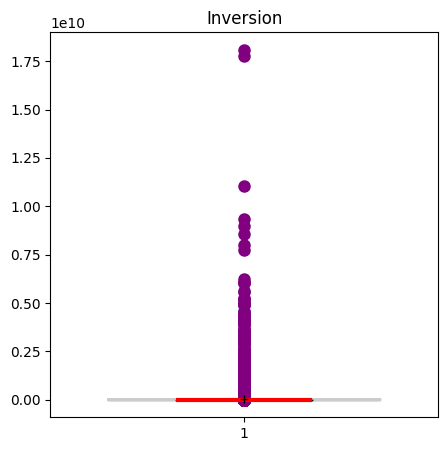

In [122]:
#Creacion de las graficas para la variable inversion
plt.figure(figsize=(5, 5))  # Tamaño del gráfico

plt.boxplot(
    df_CEV1['Inversion'],
    vert=True,          # Orientación vertical (False para horizontal)
    patch_artist=True,  # Relleno de la caja
    widths=0.7,           # Ancho de la caja
    boxprops=dict(facecolor='blue', edgecolor='black', linewidth=2, alpha=0.2), # Personaliza la caja
    medianprops=dict(color='red', linewidth=3),  # Personaliza la línea de la mediana
    flierprops=dict(marker='o', markerfacecolor='purple', markersize=8, markeredgecolor='purple'),  # Personaliza los outliers (valores atípicos)
    meanprops=dict(marker='+', markerfacecolor='black', markeredgecolor='black'), # Personaliza el marcador de la media (si se muestra con showmeans=True)
    showmeans=True,  # Mostrar u ocultar la media
    showfliers=True,  # Mostrar u ocultar outliers
    notch=True       # Activa la muesca
)

plt.title('Inversion')
plt.show()

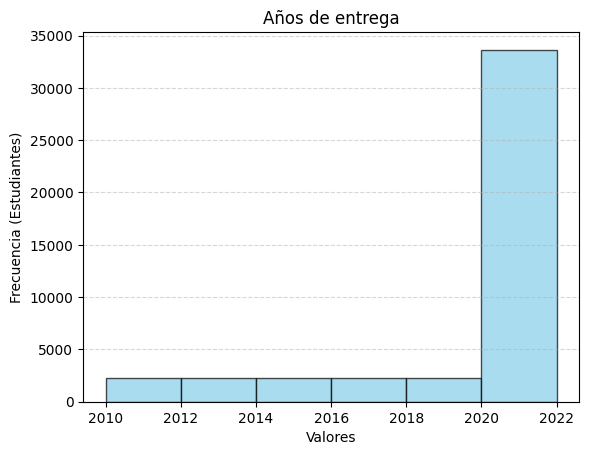

In [123]:
plt.hist(
    df_CEV1['ANIO'],
    bins=6,            # Número de barras (o lista con bordes)
    color='skyblue',   # Color de las barras
    edgecolor='black', # Borde de las barras
    alpha=0.7,         # Transparencia (0 a 1)
    density=False     # Si True, muestra densidad en lugar de frecuencia
)

plt.title('Años de entrega')
plt.xlabel('Valores')
plt.ylabel('Frecuencia (Estudiantes)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

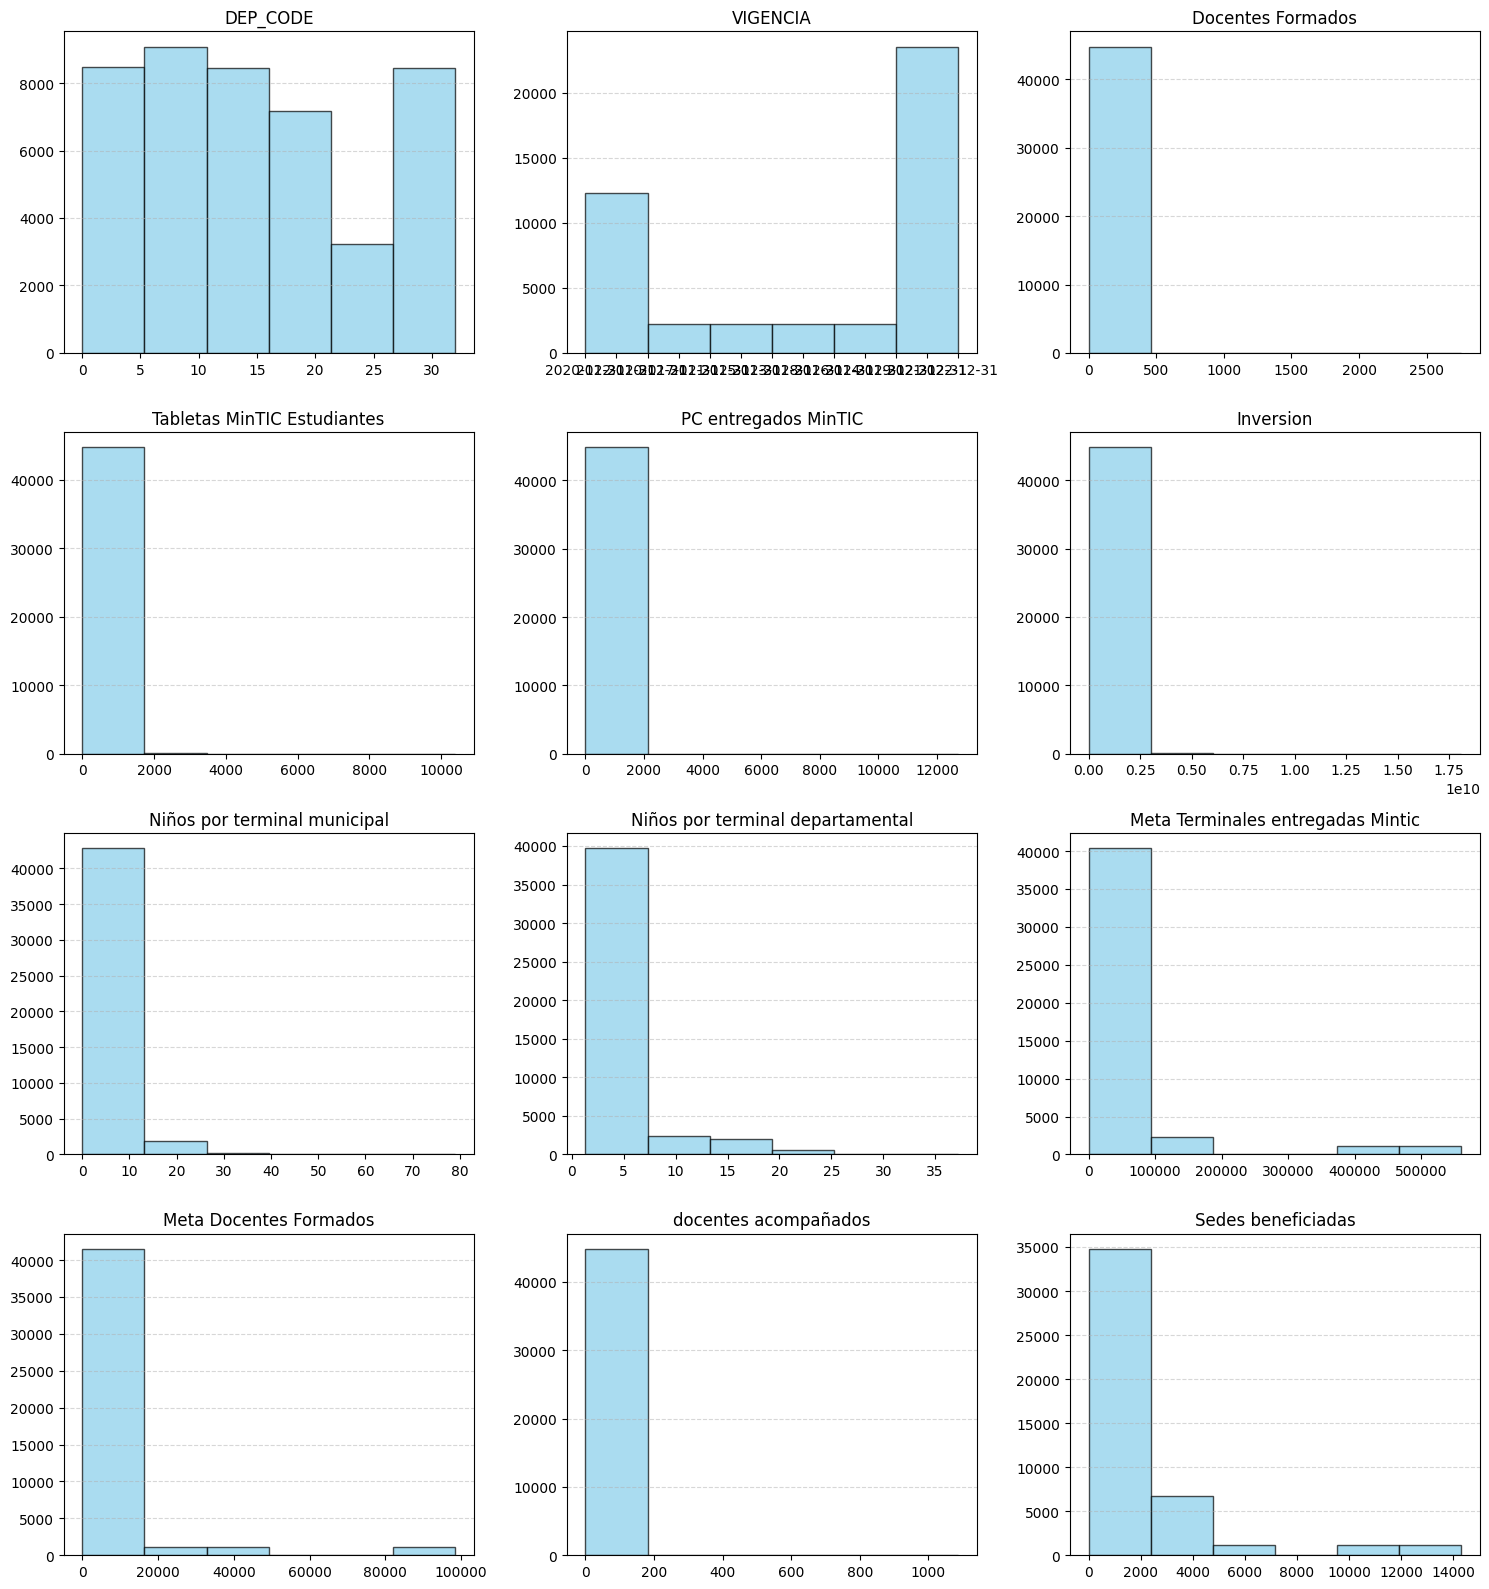

In [124]:
#En esta seccion vamos a crear varios histogramas con las variables significativas (varAll)

# Configuramos la cuadrícula
n_cols = 3  # Tú decides cuántas columnas quieres
n_rows = math.ceil(len(varAll) / n_cols)

# Creamos la figura y los ejes (axes)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Convertimos la matriz de ejes en una lista plana para iterar fácil

for i, col in enumerate(varAll):
    axes[i].hist(
        df_CEV1[col],
        bins=6,
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )
    axes[i].set_title(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Eliminamos los ejes que sobren si el número de variables no es exacto
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Ajusta automáticamente los espacios para que no se encimen
plt.show()

# **Preguntas para responder con los Datos**

1. ¿Cómo se relaciona la inversión del programa con la cantidad de equipos entregados y las sedes beneficiadas en los departamentos a lo largo del tiempo?

Variables usadas: Inversión, PC entregados MinTIC, Tabletas MinTIC Estudiantes, Sedes beneficiadas, DEPARTAMENTO, ANIO / VIGENCIA

2. ¿En qué medida los departamentos cumplen las metas establecidas de entrega de equipos y formación, y cómo varía este cumplimiento según el año?

Variables usadas: PC entregados MinTIC, Meta Terminales entregadas Mintic, Docentes Formados, Meta Docentes Formados, ANIO, DEPARTAMENTO

3. ¿Existe relación entre la cantidad de equipos entregados, la formación docente y el indicador de niños por terminal a nivel municipal y departamental?

Variables usadas: PC entregados MinTIC, Tabletas MinTIC Estudiantes, Docentes Formados, Niños por terminal municipal, Niños por terminal departamental, DEPARTAMENTO

4. ¿Qué tan eficiente es la inversión del programa en términos de equipos entregados, sedes beneficiadas y docentes acompañados en cada departamento?

Variables usadas: Inversión, PC entregados MinTIC, Tabletas MinTIC Estudiantes, docentes acompañados, Sedes beneficiadas, DEPARTAMENTO

(Por ahora estas son las preguntas, puede estar sujeto a cambios)

# **Análisis para responder las preguntas**

## **1. ¿Cómo se relaciona la inversión del programa con la cantidad de equipos entregados y las sedes beneficiadas en los departamentos a lo largo del tiempo?**

Para responder esta pregunta se analiza la distribución territorial de los equipos entregados, así como la evolución temporal de la inversión del programa, la cantidad de equipos y el número de sedes beneficiadas. El análisis combina comparaciones entre departamentos y tendencias a lo largo del periodo 2010–2022.

In [125]:
#Equipos totales entregados
df_CEV1['Equipos_totales'] = (
    df_CEV1['PC entregados MinTIC'] +
    df_CEV1['Tabletas MinTIC Estudiantes']
)

In [126]:
resumen_p1 = (
    df_CEV1
    .groupby(['DEPARTAMENTO', 'ANIO'], as_index=False)
    .agg({
        'Inversion': 'sum',
        'Equipos_totales': 'sum',
        'Sedes beneficiadas': 'sum'
    })
)

In [127]:
#La inversión por cada PC y Tableta de estudiantes
resumen_p1['Inversion_por_equipo'] = (
    resumen_p1['Inversion'] / resumen_p1['Equipos_totales']
)


resumen_p1['Equipos_por_sede'] = (
    resumen_p1['Equipos_totales'] / resumen_p1['Sedes beneficiadas']
)


/tmp/ipython-input-489466422.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_equipos, y='DEPARTAMENTO', x='Equipos_totales',


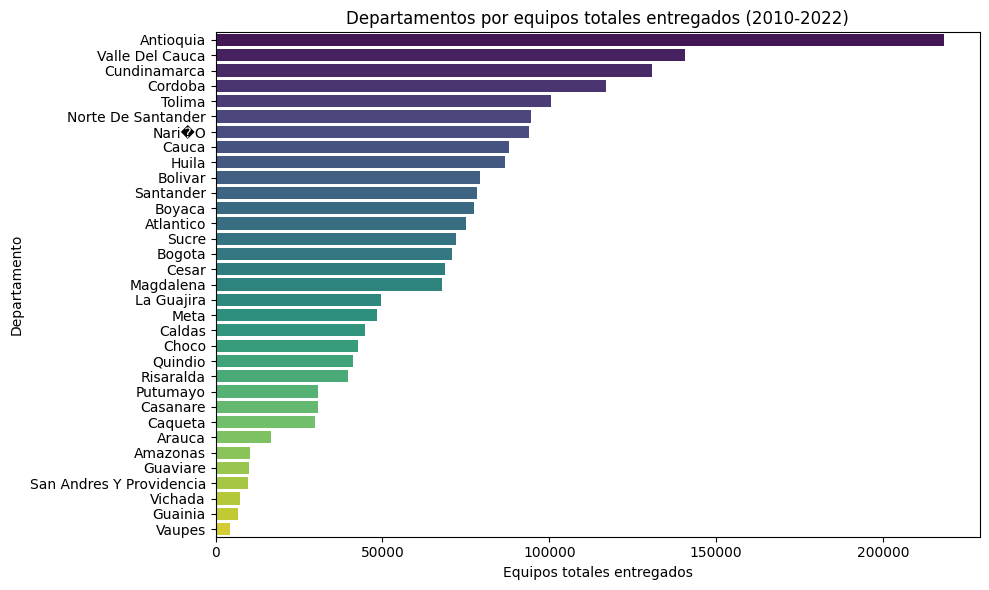

In [128]:
#Se crea un gráfico de barras horizontales con los Top 10 departamentos por equipos totales entregados (agregado 2010-2022)
dep_total = df_CEV1.groupby('DEPARTAMENTO').agg({
    'Equipos_totales': 'sum',
    'Inversion': 'sum',
    'Sedes beneficiadas': 'sum'
}).reset_index()

top10_equipos = dep_total.nlargest(33, 'Equipos_totales')

plt.figure(figsize=(10,6))
sns.barplot(data=top10_equipos, y='DEPARTAMENTO', x='Equipos_totales',
            palette='viridis')
plt.title('Departamentos por equipos totales entregados (2010-2022)')
plt.xlabel('Equipos totales entregados')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

**Interpretación:**  
La gráfica evidencia una fuerte concentración de la entrega de equipos en pocos departamentos. Antioquia lidera ampliamente la distribución, seguido por Valle del Cauca, Cundinamarca y Córdoba.  

Estos departamentos concentran una proporción significativa del total de equipos entregados a nivel nacional, lo cual puede asociarse a factores como mayor población estudiantil, mayor número de sedes educativas y una infraestructura institucional más amplia.  

En contraste, los departamentos con menor dotación presentan volúmenes considerablemente inferiores, lo que sugiere una distribución desigual del alcance territorial del programa.

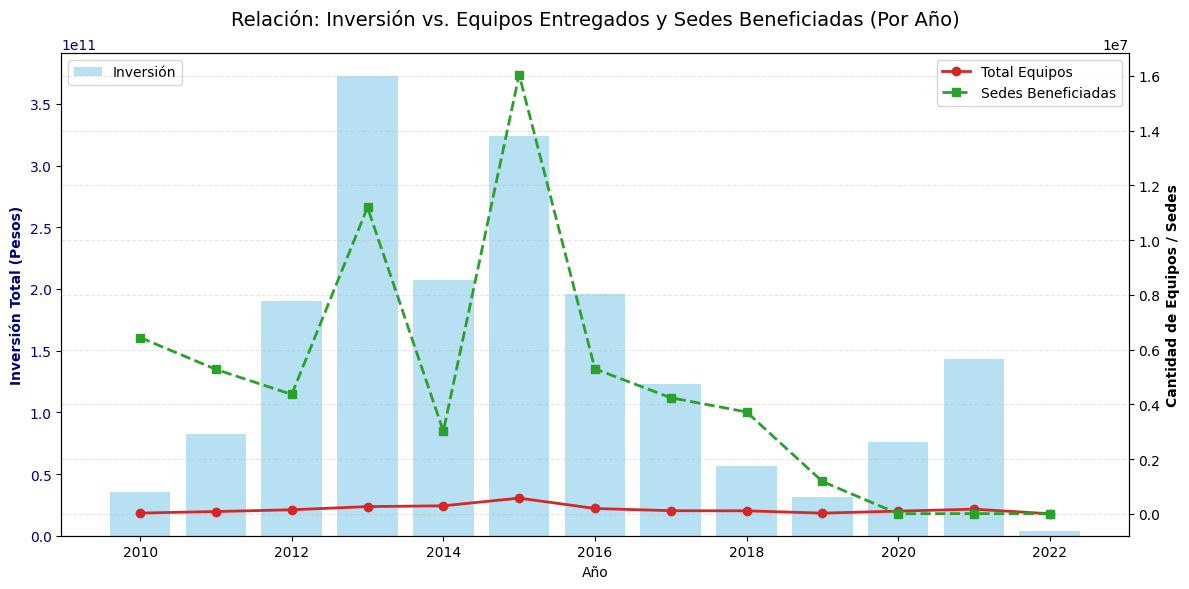

In [129]:
# 1. Preparación de datos (Agrupamos por año para ver la tendencia temporal)
df_temp = df_CEV1.groupby('ANIO').agg({
    'Inversion': 'sum',
    'PC entregados MinTIC': 'sum',
    'Tabletas MinTIC Estudiantes': 'sum',
    'Sedes beneficiadas': 'sum'
}).reset_index()

# Creamos la variable total de equipos
df_temp['Total_Equipos'] = df_temp['PC entregados MinTIC'] + df_temp['Tabletas MinTIC Estudiantes']

# 2. Configuración de la gráfica
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje Izquierdo: Inversión (Barras)
color_inv = 'skyblue'
ax1.set_xlabel('Año')
ax1.set_ylabel('Inversión Total (Pesos)', color='navy', fontweight='bold')
bars = ax1.bar(df_temp['ANIO'], df_temp['Inversion'], color=color_inv, alpha=0.6, label='Inversión')
ax1.tick_params(axis='y', labelcolor='navy')

# Eje Derecho: Equipos y Sedes (Líneas)
ax2 = ax1.twinx()
color_equipos = 'tab:red'
color_sedes = 'tab:green'

ax2.set_ylabel('Cantidad de Equipos / Sedes', color='black', fontweight='bold')
line1, = ax2.plot(df_temp['ANIO'], df_temp['Total_Equipos'], color=color_equipos, marker='o', linewidth=2, label='Total Equipos')
line2, = ax2.plot(df_temp['ANIO'], df_temp['Sedes beneficiadas'], color=color_sedes, marker='s', linestyle='--', linewidth=2, label='Sedes Beneficiadas')
ax2.tick_params(axis='y', labelcolor='black')

# Títulos y leyenda
plt.title('Relación: Inversión vs. Equipos Entregados y Sedes Beneficiadas (Por Año)', fontsize=14, pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:**  
La evolución temporal muestra que los años con mayores niveles de inversión tienden a coincidir con incrementos tanto en la cantidad de equipos entregados como en el número de sedes beneficiadas.  

Se observa un pico relevante alrededor de 2013–2015, periodo en el cual la inversión alcanza valores elevados y se refleja un aumento significativo en la cobertura del programa.  

En los años [2019 - 2022] se tuvo una muy pocas sedes beneficiadas esto se puede deber a la pandemiaEl año de mayor entrega de equipos, de mayor inversion y mas sedes beneficiadas esta en el año 2013.

Sin embargo, la relación no es perfectamente proporcional: existen años en los que, a pesar de una inversión considerable, el número de sedes o equipos no crece en la misma magnitud, lo que sugiere variaciones en la eficiencia operativa, costos logísticos o cambios en el enfoque del programa.

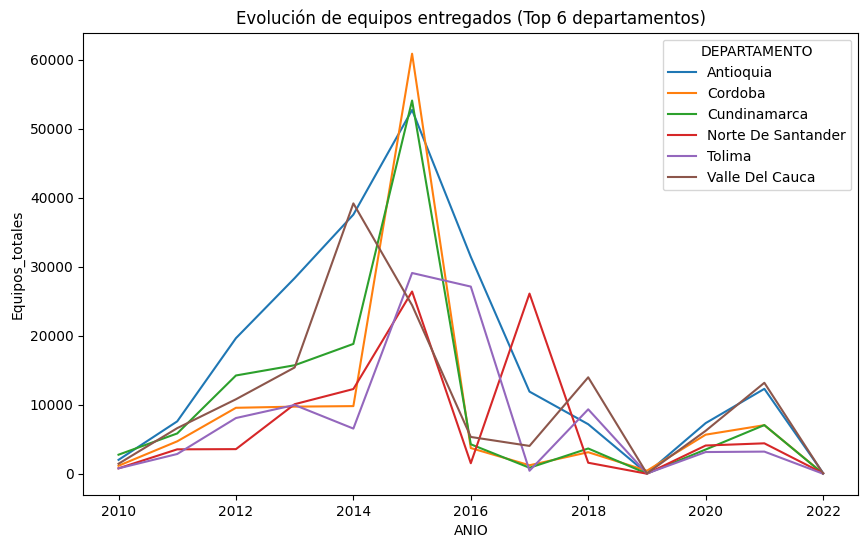

In [130]:
top_deptos = (
    resumen_p1.groupby('DEPARTAMENTO')['Equipos_totales']
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

df_plot = resumen_p1[resumen_p1['DEPARTAMENTO'].isin(top_deptos)]

plt.figure(figsize=(10,6))
sns.lineplot(data=df_plot, x='ANIO', y='Equipos_totales', hue='DEPARTAMENTO')
plt.title("Evolución de equipos entregados (Top 6 departamentos)")
plt.show()

**Interpretación:**  
Los principales departamentos presentan trayectorias similares en la evolución de la entrega de equipos, con incrementos progresivos hasta alcanzar picos alrededor de 2014–2015, seguidos por una reducción notable en años posteriores.  

Este comportamiento sugiere una fase de expansión intensa del programa en sus primeros años, seguida de una etapa de desaceleración o reorientación de la estrategia.  

La sincronía entre departamentos indica que los cambios en la entrega de equipos responden principalmente a decisiones de política pública a nivel nacional más que a dinámicas aisladas de cada territorio.

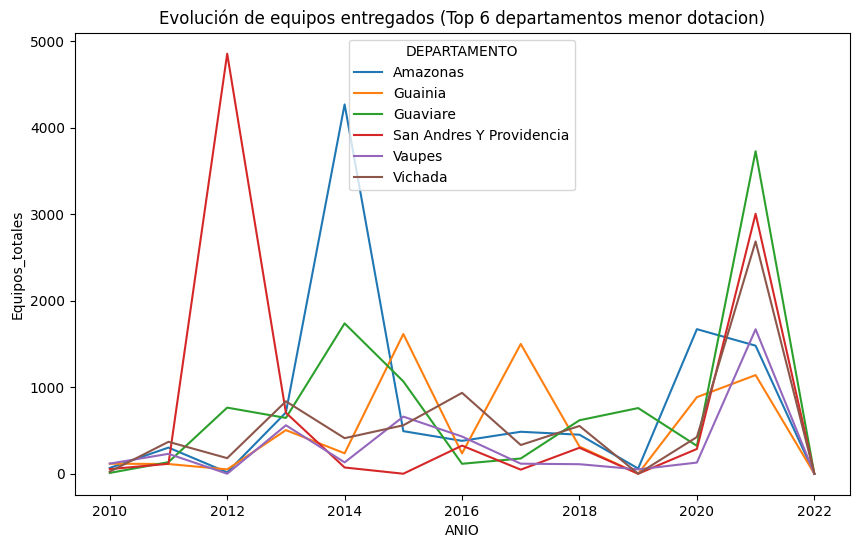

In [131]:
top_deptos = (
    resumen_p1.groupby('DEPARTAMENTO')['Equipos_totales']
    .sum()
    .sort_values(ascending=True)
    .head(6)
    .index
)

df_plot = resumen_p1[resumen_p1['DEPARTAMENTO'].isin(top_deptos)]

plt.figure(figsize=(10,6))
sns.lineplot(data=df_plot, x='ANIO', y='Equipos_totales', hue='DEPARTAMENTO')
plt.title("Evolución de equipos entregados (Top 6 departamentos menor dotacion)")
plt.show()

**Interpretación:**  
Los departamentos con menor dotación presentan volúmenes bajos e irregulares de entrega de equipos a lo largo del tiempo.  

Se observan picos puntuales en algunos años específicos, lo que sugiere intervenciones focalizadas más que una estrategia sostenida de cobertura.  

Esta alta variabilidad refuerza la idea de una asignación diferenciada de recursos, posiblemente condicionada por factores geográficos, demográficos y de accesibilidad, lo que impacta directamente la equidad territorial del programa.

In [132]:
#Sumar todos los valores de inversion , equipos entregados y instituciones educativas
df_CEV1['Inversion'].sum()

np.int64(1841506669478)

In [133]:
df_CEV1['Equipos_totales'].sum()

np.int64(2081674)

In [134]:
df_CEV1['Sedes beneficiadas'].sum()

np.int64(60759698)

### **Respuesta a la pregunta 1:**

El análisis muestra que existe una relación clara entre la inversión del programa y la cantidad de equipos entregados, así como con el número de sedes beneficiadas a lo largo del tiempo. Los periodos de mayor inversión se asocian con una expansión significativa de la cobertura del programa,  especialmente en departamentos como Antioquia, Cundinamarca y Valle del Cauca, los cuales concentran los mayores volúmenes de entrega a lo largo del periodo analizado.

No obstante, la distribución de los recursos no es homogénea entre departamentos. Mientras algunos concentran una gran proporción de los equipos entregados, otros presentan una participación limitada y discontinua.  

Esto indica que, además del nivel de inversión, la implementación del programa está influenciada por factores territoriales y estratégicos que afectan tanto la eficiencia como la equidad en la asignación de los recursos.

## **2. ¿En qué medida los departamentos cumplen las metas establecidas de entrega de equipos y formación, y cómo varía este cumplimiento según el año?**

In [135]:
#Porcentaje de metricas de cumplimiento
df_CEV1['Cumplimiento_equipos'] = (
    df_CEV1['PC entregados MinTIC'] /
    df_CEV1['Meta Terminales entregadas Mintic']
) * 100

#Porcentaje de docentes formados
df_CEV1['Cumplimiento_docentes'] = (
    df_CEV1['Docentes Formados'] /
    df_CEV1['Meta Docentes Formados']
) * 100

print(f'{df_CEV1['Cumplimiento_docentes'].count()} {df_CEV1['Cumplimiento_equipos'].count()}')

44280 44840


In [136]:
resumen_p2 = (
    df_CEV1.groupby(['DEPARTAMENTO', 'ANIO'])
    .agg({
        'Cumplimiento_equipos': 'mean',
        'Cumplimiento_docentes': 'mean'
    })
    .reset_index()
)

resumen_p2

,DEPARTAMENTO,ANIO,Cumplimiento_equipos,Cumplimiento_docentes
0,Amazonas,2010,0.026185,inf
1,Amazonas,2011,0.036825,0.000000
2,Amazonas,2012,0.002003,0.028293
3,Amazonas,2013,0.043212,0.034889
4,Amazonas,2014,inf,inf
...,...,...,...,...
424,Vichada,2018,0.000000,0.000000
425,Vichada,2019,0.000000,0.583333
426,Vichada,2020,0.002389,0.003000
427,Vichada,2021,0.084351,0.003365


In [137]:
#Sacar las posiciones del dataset donde cumplimiento de equipos es igual a infinito
resumen_p2[resumen_p2['Cumplimiento_equipos'] == np.inf]

,DEPARTAMENTO,ANIO,Cumplimiento_equipos,Cumplimiento_docentes
4,Amazonas,2014,inf,inf
17,Antioquia,2014,inf,inf
30,Arauca,2014,inf,inf
43,Atlantico,2014,inf,inf
56,Bogota,2014,inf,inf
69,Bolivar,2014,inf,inf
82,Boyaca,2014,inf,inf
95,Caldas,2014,inf,inf
108,Caqueta,2014,inf,inf
121,Casanare,2014,inf,inf


In [138]:
#Sacar las posiciones del dataset donde cumplimiento de docentes es igual a infinito
resumen_p2[resumen_p2['Cumplimiento_docentes'] != np.inf]

,DEPARTAMENTO,ANIO,Cumplimiento_equipos,Cumplimiento_docentes
1,Amazonas,2011,0.036825,0.000000
2,Amazonas,2012,0.002003,0.028293
3,Amazonas,2013,0.043212,0.034889
5,Amazonas,2015,0.006071,0.000000
6,Amazonas,2016,0.000248,0.040041
...,...,...,...,...
424,Vichada,2018,0.000000,0.000000
425,Vichada,2019,0.000000,0.583333
426,Vichada,2020,0.002389,0.003000
427,Vichada,2021,0.084351,0.003365


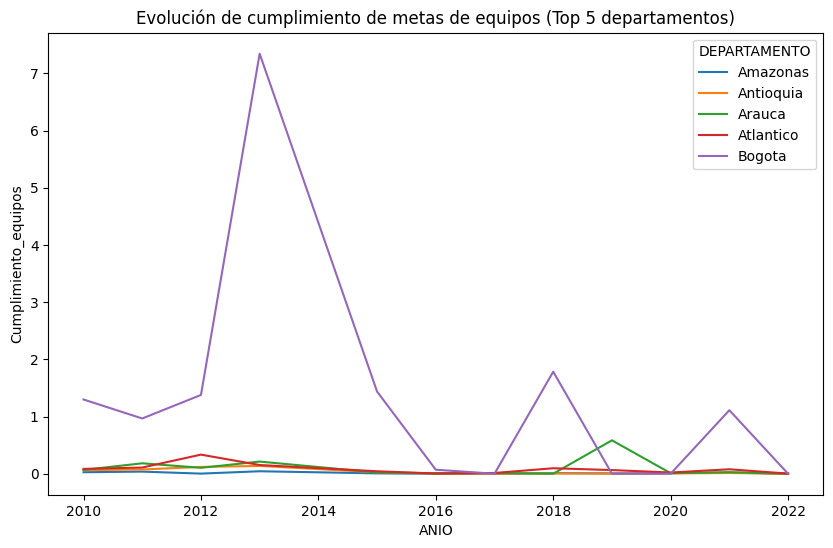

In [139]:
top_deptos = (
    resumen_p2
    .groupby('DEPARTAMENTO')['Cumplimiento_equipos']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)
df_plot = resumen_p2[resumen_p2['DEPARTAMENTO'].isin(top_deptos)]
plt.figure(figsize=(10,6))
sns.lineplot(data=df_plot, x='ANIO', y='Cumplimiento_equipos', hue='DEPARTAMENTO')
plt.title("Evolución de cumplimiento de metas de equipos (Top 5 departamentos)")
plt.show()

### **Interpretación:**

La Figura muestra la evolución temporal del cumplimiento de metas de entrega de equipos para los cinco departamentos con mayor tasa promedio de cumplimiento durante 2010-2022.

**Observaciones principales:**

1. **Patrón de cumplimiento errático**: El comportamiento de Bogotá domina visualmente el gráfico con valores de cumplimiento extremadamente altos en el período 2012-2014 (alcanzando un pico de aproximadamente 7.0, es decir, 700% de cumplimiento), seguido de una caída abrupta. Este comportamiento atípico sugiere posibles ajustes metodológicos en el establecimiento de metas o sobre-ejecuciones excepcionales en años específicos.

2. **Cumplimiento generalmente bajo**: Excluyendo el caso atípico de Bogotá, los demás departamentos (Amazonas, Antioquia, Arauca, Atlántico) muestran tasas de cumplimiento que oscilan entre 0 y aproximadamente 0.5 (0-50%), consistentemente por debajo del 100%.

3. **Alta volatilidad**: Se observan fluctuaciones abruptas año tras año, sin patrones estables de cumplimiento. Esto indica que los departamentos no mantienen niveles consistentes de ejecución en el tiempo.

4. **Convergencia hacia sub-cumplimiento**: En años recientes (2020-2022), todos los departamentos, incluyendo Bogotá, convergen hacia niveles de cumplimiento cercanos a 0, sugiriendo un deterioro generalizado en la capacidad de alcanzar las metas establecidas.

5. **Sin mejora sostenida**: No existe evidencia de aprendizaje organizacional o mejora progresiva en el cumplimiento. Los departamentos no muestran tendencias ascendentes sostenidas que indiquen fortalecimiento de capacidades de ejecución.

**Implicación crítica**: La extrema variabilidad y los niveles predominantemente bajos de cumplimiento (excluyendo outliers) sugieren desalineación sistemática entre las metas establecidas y la capacidad real de ejecución del programa. El caso de Bogotá en 2013 requiere verificación metodológica para descartar errores en el cálculo de metas o cumplimiento.

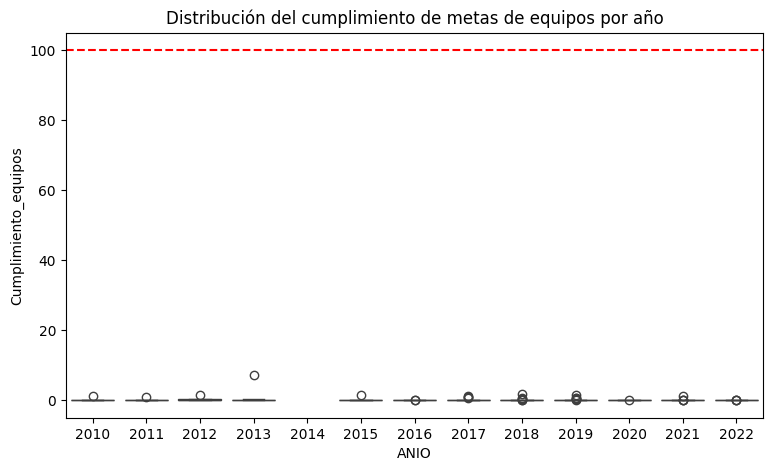

In [140]:
plt.figure(figsize=(9,5))
sns.boxplot(data=resumen_p2, x='ANIO', y='Cumplimiento_equipos')
plt.axhline(100, color='red', linestyle='--')
plt.title("Distribución del cumplimiento de metas de equipos por año")
plt.show()

### **Interpretación:**

La figura presenta la distribución del cumplimiento de metas de entrega de equipos para todos los departamentos en cada año mediante diagramas de caja. La línea roja discontinua marca el umbral del 100% (cumplimiento exacto de la meta).

**Hallazgos clave:**

1. **Cumplimiento mediano consistentemente bajo**: La mediana (línea central de cada caja) permanece cercana a 0% en todos los años analizados, ubicándose muy por debajo del umbral del 100%. Esto confirma que el sub-cumplimiento severo es la norma, no la excepción, para la mayoría de los departamentos.

2. **Distribuciones extremadamente concentradas**: Las cajas son muy pequeñas (reducida diferencia entre Q1 y Q3), con los cuartiles 25, 50 y 75 todos muy próximos a cero. Esto indica que la mayoría de los departamentos (75% o más) tienen cumplimientos inferiores al 10-20% en la mayoría de los años.

3. **Outliers extremos**: En varios años (especialmente 2013-2014, 2018) se observan valores atípicos marcadamente altos que distorsionan la escala del gráfico. Estos outliers corresponden probablemente a casos como Bogotá identificado en el gráfico anterior, donde el cumplimiento supera el 100% de manera excepcional.

4. **Ausencia de valores en el rango óptimo**: Prácticamente no existen valores concentrados en el rango 80-120% (cumplimiento aceptable), lo que refuerza que el programa enfrenta dificultades sistemáticas para alcanzar niveles de ejecución cercanos a lo planificado.

5. **Estabilidad temporal del problema**: El patrón se repite consistentemente a lo largo de los 13 años. No hay evidencia de mejora: los años 2010-2012 muestran el mismo problema estructural que 2020-2022.

6. **Bimodalidad implícita**: La combinación de medianas cercanas a cero y outliers extremos sugiere una distribución bimodal: la mayoría de departamentos con cumplimiento muy bajo y unos pocos casos excepcionales con sobre-cumplimiento dramático.

**Conclusión crítica**: El gráfico revela un problema sistémico y persistente en el cumplimiento de metas del programa. La concentración de la distribución en valores cercanos a cero indica que las metas establecidas no reflejan las capacidades reales de ejecución de la mayoría de los territorios. Esta desconexión entre planificación y realidad operativa requiere revisión urgente de los procesos de establecimiento de metas o, alternativamente, intervenciones sustanciales para fortalecer la capacidad de ejecución territorial.

## **Respuesta a la Pregunta 2:**

### **Hallazgo principal: Sub-cumplimiento sistemático**

El cumplimiento de las metas establecidas es sistemática y severamente inferior al 100% en la gran mayoría de los departamentos y años analizados. La mediana de cumplimiento se ubica consistentemente cerca del 0%, indicando que más del 50% de las observaciones departamento-año muestran tasas de cumplimiento inferiores al 10-20%. Este patrón no es ocasional ni transitorio: se mantiene invariable durante los 13 años del estudio.

### **Heterogeneidad extrema: Outliers vs. mayoría**

Existe una dicotomía marcada entre el comportamiento de la mayoría de departamentos y casos atípicos excepcionales:

- **Mayoría (>75% de casos)**: Cumplimiento muy bajo (<20%), reflejado en las distribuciones concentradas cerca de cero en los boxplots.
- **Casos atípicos (<5% de casos)**: Sobre-cumplimientos extremos (300-700%), como el observado en Bogotá 2013, que requieren verificación metodológica para descartar errores en el cálculo de metas o en el registro de resultados.

Esta heterogeneidad extrema sugiere que las metas no se ajustan apropiadamente a las capacidades específicas de cada territorio, resultando en objetivos inalcanzables para la mayoría e insuficientemente ambiciosos para unos pocos casos.

### **Ausencia de aprendizaje organizacional**

No se observa tendencia de mejora en el cumplimiento a lo largo del período:

- Los años iniciales (2010-2012) muestran el mismo patrón de bajo cumplimiento que los años finales (2020-2022)
- No existe evidencia de fortalecimiento progresivo de capacidades de ejecución
- Las fluctuaciones interanuales son erráticas, sin convergencia hacia niveles más altos y estables

Esta estabilidad del problema a lo largo de 13 años indica que los desafíos estructurales del programa (sean estos de planificación, capacidad administrativa, logística, o coordinación interinstitucional) no han sido efectivamente abordados.

### **Conclusión**

El programa Computadores para Educar enfrenta un desafío sistémico y persistente en el cumplimiento de sus metas programáticas. El sub-cumplimiento severo y generalizado, combinado con la ausencia de mejora a lo largo de 13 años, indica que el problema es estructural y no coyuntural. Abordar esta situación requiere intervenciones sustanciales en los procesos de planificación, fortalecimiento de capacidades territoriales, o ambos. Sin estos cambios, el programa continuará mostrando brechas significativas entre objetivos planificados y resultados alcanzados.

## **3. ¿Existe relación entre la cantidad de equipos entregados, la formación docente y el indicador de niños por terminal a nivel municipal y departamental?**

In [141]:
# Equipos totales entregados (PC + Tabletas)
df_CE["Equipos_totales"] = df_CE["PC entregados MinTIC"] + df_CE["Tabletas MinTIC Estudiantes"]

# Revisar que existan las columnas clave
cols_clave = [
    "Equipos_totales",
    "Docentes Formados",
    "Niños por terminal municipal",
    "Niños por terminal departamental",
    "ANIO",
    "DEPARTAMENTO"
]

print("Columnas clave presentes:", all(c in df_CE.columns for c in cols_clave))
df_CE[cols_clave].head()

Columnas clave presentes: True


,Equipos_totales,Docentes Formados,Niños por terminal municipal,Niños por terminal departamental,ANIO,DEPARTAMENTO
0,0,0,2.0,5.00,2020,Boyaca
1,0,0,3.0,3.00,2020,Huila
2,0,0,6.0,5.00,2020,Boyaca
3,0,0,2.0,4.49,2020,Antioquia
4,0,0,1.0,5.00,2020,Boyaca


In [142]:
cols_num = [
    "Equipos_totales",
    "Docentes Formados",
    "Niños por terminal municipal",
    "Niños por terminal departamental"
]

data = df_CE[["ANIO","DEPARTAMENTO"] + cols_num].copy()

# Asegurar numérico
for c in cols_num:
    data[c] = pd.to_numeric(data[c], errors="coerce")

# Quitar inf y NaN
data = data.replace([np.inf, -np.inf], np.nan).dropna()

data.describe()

,ANIO,Equipos_totales,Docentes Formados,Niños por terminal municipal,Niños por terminal departamental
count,44855.000000,44855.000000,44855.000000,44855.000000,44855.000000
mean,2019.300725,46.408962,6.502107,4.947366,5.350109
std,3.187237,288.474223,43.549951,4.247536,3.779122
min,2010.000000,0.000000,0.000000,0.000000,1.300000
25%,2020.000000,0.000000,0.000000,2.000000,3.230000
50%,2021.000000,0.000000,0.000000,4.000000,4.490000
75%,2021.000000,0.000000,0.000000,6.000000,5.510000
max,2022.000000,13220.000000,2756.000000,78.980000,37.220000


In [143]:
corr_pearson = data[cols_num].corr(method="pearson")
corr_pearson

,Equipos_totales,Docentes Formados,Niños por terminal municipal,Niños por terminal departamental
Equipos_totales,1.000000,0.371874,0.114368,0.091569
Docentes Formados,0.371874,1.000000,0.081035,0.055651
Niños por terminal municipal,0.114368,0.081035,1.000000,0.692210
Niños por terminal departamental,0.091569,0.055651,0.692210,1.000000


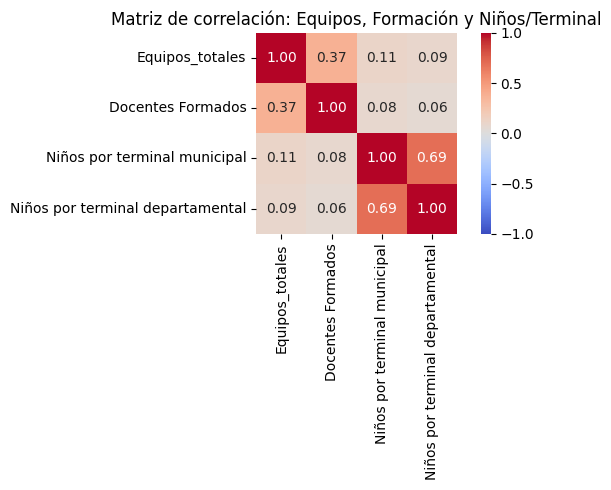

In [144]:
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    square=True,
    vmin=-1, vmax=1,
    center=0,
    cmap="coolwarm"
)
plt.title("Matriz de correlación: Equipos, Formación y Niños/Terminal")
plt.tight_layout()
plt.show()

### **Interpretación:**

La matriz de correlación de Pearson cuantifica la fuerza y dirección de las relaciones lineales entre cuatro variables clave del programa: Equipos totales entregados, Docentes Formados, Niños por terminal municipal y Niños por terminal departamental. Los coeficientes oscilan entre -1 (correlación negativa perfecta) y +1 (correlación positiva perfecta).

**Criterios de interpretación:**
- |r| < 0.3: Correlación débil o negligible
- 0.3 ≤ |r| < 0.7: Correlación moderada
- |r| ≥ 0.7: Correlación fuerte

**Síntesis de interpretación**

1. **Coordinación moderada pero mejorable**: Equipos y formación docente están moderadamente asociados (r=0.37), indicando coordinación imperfecta entre componentes del programa.

2. **Desconexión con impacto en acceso**: Las correlaciones negligibles entre dotación/capacitación y niños por terminal (r≈0.09-0.11) revelan que incrementar estos inputs no se traduce linealmente en mejoras visibles del ratio estudiantes/dispositivos.

3. **Factores externos dominantes**: Los indicadores de acceso parecen estar más influenciados por factores demográficos y fuentes alternativas de equipos que por la dotación específica del programa CPE.

4. **Consistencia metodológica**: La correlación moderada-fuerte entre ambas mediciones de niños por terminal (r=0.69) valida la fiabilidad de los datos.

### **Implicación para evaluación de impacto:**

Los hallazgos sugieren que evaluar el impacto del programa CPE únicamente mediante indicadores agregados de acceso (niños por terminal) puede ser insuficiente o incluso engañoso, ya que estos indicadores responden a múltiples factores más allá del programa.

## **Respuesta a la Pregunta 3:**

### **Hallazgo 1: Coordinación imperfecta entre dotación y capacitación**

La correlación entre Equipos totales y Docentes Formados es positiva y moderada (r = 0.37), indicando que el programa intenta coordinar estos dos componentes esenciales. Departamentos o períodos con mayor entrega de equipos tienden a tener mayor actividad de formación docente. Sin embargo, esta coordinación está lejos de ser perfecta:

**Causas posibles de la coordinación imperfecta:**

1. **Ejecución operativa independiente**: Los componentes de dotación y capacitación pueden estar gestionados por equipos diferentes dentro del programa, con presupuestos, cronogramas y metas separados, resultando en ejecución desincronizada.

2. **Desfases temporales**: La estrategia óptima puede involucrar capacitar docentes antes de entregar equipos (preparación anticipada) o después (capacitación una vez instalados los dispositivos). Estos desfases intencionados diluyen la correlación sincrónica.

3. **Prioridades territoriales diferenciadas**: Algunos departamentos pueden tener déficit más crítico en equipos, mientras otros tienen mayor necesidad de capacitación docente. La focalización diferenciada según necesidades locales puede explicar la coordinación imperfecta al agregar datos.

### **Hallazgo 2: Desconexión crítica con indicadores de acceso**

El hallazgo más significativo y contra-intuitivo del análisis es la ausencia de correlación lineal entre equipos entregados/docentes formados y los indicadores de niños por terminal. Las correlaciones son negligibles (r ≈ 0.09-0.11), cercanas a cero.

**¿Por qué incrementar equipos NO mejora visiblemente el indicador de acceso?**

Este resultado aparentemente paradójico tiene explicaciones estructurales importantes:

#### **Explicación 1: El denominador se mueve tanto o más que el numerador**

El indicador "niños por terminal" tiene estructura de ratio:
```
Niños por terminal = Población estudiantil / (Equipos CPE + Equipos otras fuentes)
```
Para que el indicador mejore (disminuya), el numerador debe crecer más lentamente que el denominador. Sin embargo:

- **Crecimiento poblacional**: La población estudiantil colombiana ha crecido durante el período analizado debido a expansión de cobertura educativa y crecimiento demográfico. Si este crecimiento es similar o superior a la tasa de entrega de equipos, el indicador permanece estable o empeora.

- **Efecto dilución temporal**: Equipos entregados hace 5-7 años pueden estar fuera de servicio por obsolescencia o daño, mientras la población estudiantil se acumula. El efecto neto de entregas nuevas se ve constantemente erosionado por bajas de equipos antiguos.

#### **Explicación 2: El indicador es imperfecto para medir impacto del programa**

"Niños por terminal" captura acceso cuantitativo general pero no distingue:
- Equipos funcionales vs. equipos dañados u obsoletos
- Equipos con/sin conectividad a internet
- Equipos con/sin software educativo
- Frecuencia real de uso por estudiantes

El programa CPE puede estar mejorando dimensiones cualitativas (equipos más modernos, mejor mantenimiento, software pedagógico) que no se reflejan en el simple conteo de dispositivos del indicador.

### **Conclusión:**

**Sí existe relación entre equipos entregados y formación docente (r=0.37), pero es moderada e imperfecta**, indicando coordinación operativa mejorable entre estos componentes del programa.

**No existe relación lineal significativa entre dotación/capacitación y el indicador de niños por terminal (r≈0.09-0.11)**. Este hallazgo contra-intuitivo no indica fracaso del programa sino limitaciones del indicador y complejidad de factores causales (demografía, múltiples fuentes de equipos, heterogeneidad territorial) que median la relación.

Para evaluar apropiadamente el impacto del programa en acceso estudiantil a tecnología se requieren metodologías más sofisticadas que simples correlaciones agregadas, incluyendo controles por factores confusores y análisis de efectos heterogéneos territoriales.

## **4. ¿Qué tan eficiente es la inversión del programa en términos de equipos entregados, sedes beneficiadas y docentes acompañados en cada departamento?**

In [145]:
# Variables según diccionario
cols = [
    "ANIO", "DEPARTAMENTO",
    "Inversion",
    "PC entregados MinTIC",
    "Tabletas MinTIC Estudiantes",
    "Sedes beneficiadas",
    "docentes acompañados"
]

data = df_CE[cols].copy()

# Convertir a numérico donde aplique
num_cols = [
    "Inversion",
    "PC entregados MinTIC",
    "Tabletas MinTIC Estudiantes",
    "Sedes beneficiadas",
    "docentes acompañados"
]
for c in num_cols:
    data[c] = pd.to_numeric(data[c], errors="coerce")

# Equipos totales entregados (PC + tabletas)
data["Equipos_totales"] = data["PC entregados MinTIC"] + data["Tabletas MinTIC Estudiantes"]

data.head()

,ANIO,DEPARTAMENTO,Inversion,PC entregados MinTIC,Tabletas MinTIC Estudiantes,Sedes beneficiadas,docentes acompañados,Equipos_totales
0,2020,Boyaca,0,0,0,0,0,0
1,2020,Huila,0,0,0,0,0,0
2,2020,Boyaca,0,0,0,0,0,0
3,2020,Antioquia,0,0,0,0,0,0
4,2020,Boyaca,0,0,0,0,0,0


In [146]:
#Sumamos inversión y resultados por departamento (porque la inversión es acumulativa).
dep = data.groupby("DEPARTAMENTO", as_index=False).agg({
    "Inversion": "sum",
    "Equipos_totales": "sum",
    "Sedes beneficiadas": "sum",
    "docentes acompañados": "sum"
})

# Evitar división por cero: si algún resultado es 0, lo ponemos NaN
for c in ["Equipos_totales", "Sedes beneficiadas", "docentes acompañados"]:
    dep.loc[dep[c] == 0, c] = np.nan

# Métricas de eficiencia (menor = mejor)
dep["Costo_por_equipo"] = dep["Inversion"] / dep["Equipos_totales"]
dep["Costo_por_sede"] = dep["Inversion"] / dep["Sedes beneficiadas"]
dep["Costo_por_docente_acompanado"] = dep["Inversion"] / dep["docentes acompañados"]

dep.head()

,DEPARTAMENTO,Inversion,Equipos_totales,Sedes beneficiadas,docentes acompañados,Costo_por_equipo,Costo_por_sede,Costo_por_docente_acompanado
0,Amazonas,7066933343,10381.0,542009,118,680756.511222,13038.405899,59889265.618644
1,Antioquia,200060368756,218185.0,6774705,3415,916929.984903,29530.49155,58582831.260908
2,Arauca,15434773657,16454.0,379435,255,938056.014161,40678.307634,60528524.145098
3,Atlantico,68411573184,74978.0,1247005,2395,912421.952893,54860.704796,28564331.183299
4,Bogota,76584569942,70773.0,54385,1776,1082115.6365,1408192.883001,43121942.53491


In [147]:
#Top 10 más eficientes (menor costo) por métrica
top10_deps = dep.sort_values("Costo_por_equipo").head(10)

tabla_top10 = top10_deps[[
    "DEPARTAMENTO",
    "Costo_por_equipo",
    "Costo_por_sede",
    "Costo_por_docente_acompanado"
]].reset_index(drop=True)

display(tabla_top10)

,DEPARTAMENTO,Costo_por_equipo,Costo_por_sede,Costo_por_docente_acompanado
0,Amazonas,680756.511222,13038.405899,59889265.618644
1,Quindio,757641.42838,47784.015613,53967482.925347
2,Guainia,762941.388251,10489.902545,98404767.134615
3,Cordoba,771691.473218,55539.402701,59575497.988786
4,Sucre,789385.00318,40339.034869,80988427.470085
5,Cundinamarca,791243.104165,16465.772562,45165412.984729
6,Norte De Santander,813743.193724,35440.453896,46454699.867594
7,Cesar,816826.397367,41439.386452,52577463.190075
8,Tolima,830579.639389,32792.366571,59751233.843348
9,Valle Del Cauca,846178.264906,52284.316621,48347299.084484


/tmp/ipython-input-1099190225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_top10, x="Costo_por_equipo", y="DEPARTAMENTO", palette="viridis")


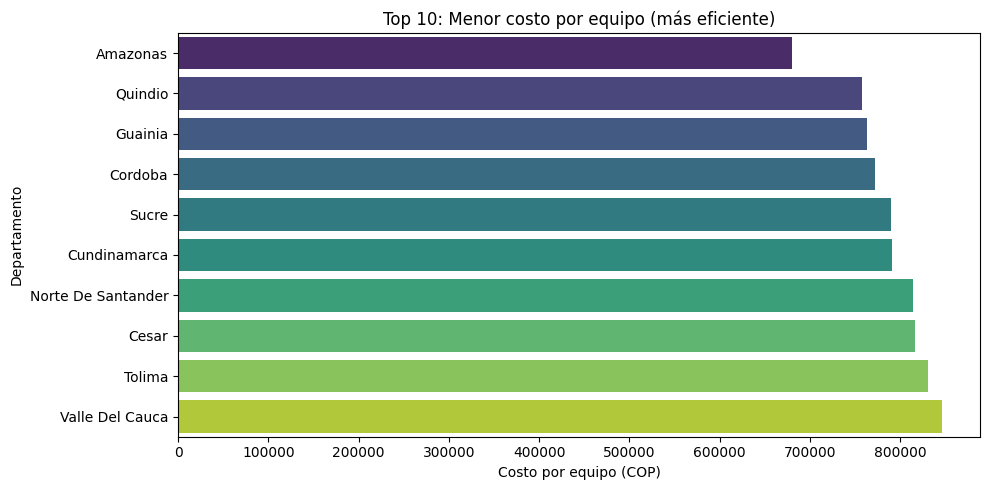

In [148]:
#Gráfica: Top 10 (Costo por equipo)
plt.figure(figsize=(10,5))
sns.barplot(data=tabla_top10, x="Costo_por_equipo", y="DEPARTAMENTO", palette="viridis")
plt.title("Top 10: Menor costo por equipo (más eficiente)")
plt.xlabel("Costo por equipo (COP)")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### **Interpretación:**

**Hallazgos principales:**

- **Rango de eficiencia**: Los costos oscilan entre ~700,000 COP (Amazonas, más eficiente) y ~850,000 COP (Valle del Cauca, décimo lugar).

- **Amazonas lidera**: Con aproximadamente $700,000 COP por equipo, Amazonas demuestra la mayor eficiencia en dotación tecnológica, posiblemente por estrategias de compra optimizadas o enfoque en equipos apropiados para contextos rurales.

- **Diferencias moderadas**: El Top 10 muestra costos relativamente homogéneos (variación ~20%), indicando que existe un grupo de departamentos que ha estandarizado procesos de adquisición eficientes.

- **Departamentos diversos**: El Top 10 incluye tanto territorios grandes (Cundinamarca, Valle del Cauca, Norte de Santander) como pequeños (Amazonas, Quindío, Guainía), demostrando que la eficiencia no depende únicamente del tamaño departamental.

**Contexto**: Departamentos fuera del Top 10 presentan costos superiores a $1,000,000 COP por equipo, evidenciando brechas significativas que pueden asociarse a sobrecostos logísticos o procesos menos optimizados.

/tmp/ipython-input-2003753453.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_top10, x="Costo_por_sede", y="DEPARTAMENTO", palette="viridis")


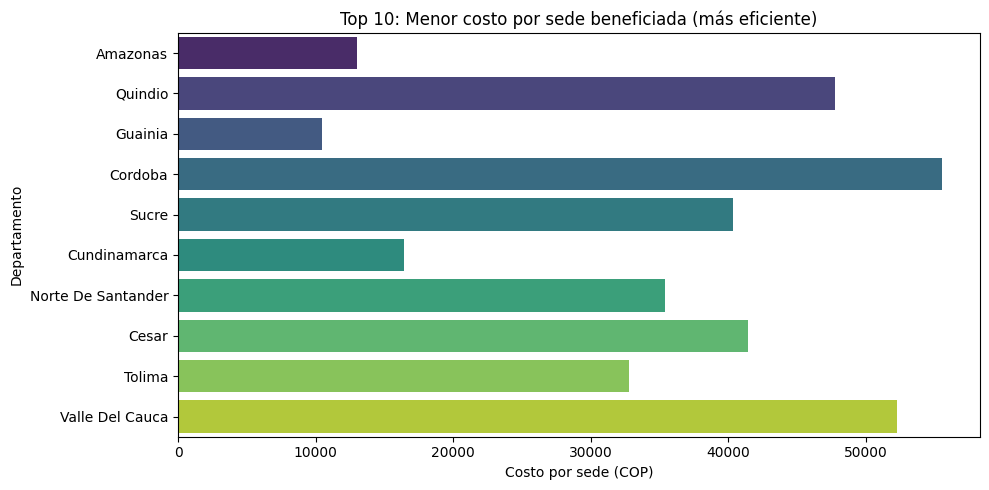

In [149]:
#Gráfica: Top 10 (Costo por sede)

plt.figure(figsize=(10,5))
sns.barplot(data=tabla_top10, x="Costo_por_sede", y="DEPARTAMENTO", palette="viridis")
plt.title("Top 10: Menor costo por sede beneficiada (más eficiente)")
plt.xlabel("Costo por sede (COP)")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### **Interpretación:**

**Observaciones clave:**

- **Heterogeneidad extrema**: A diferencia del costo por equipo, esta métrica muestra mayor dispersión. Los valores van desde ~8,000 COP (Guainía, Amazonas) hasta ~55,000 COP (Valle del Cauca, Córdoba).

- **Guainía y Amazonas: casos excepcionales**: Con costos por sede dramáticamente bajos (~$8,000-$10,000 COP), estos departamentos priorizan **cobertura amplia sobre profundidad**, beneficiando muchas instituciones con inversión modesta por cada una.

- **Estrategias diferenciadas**: La variación 7x entre el primero y décimo lugar sugiere estrategias territoriales distintas:
  - **Cobertura amplia**: Muchas sedes, poca inversión por sede (Guainía, Amazonas)
  - **Profundidad**: Pocas sedes, alta inversión por sede (Valle, Córdoba)

- **Quindío: balance efectivo**: Con ~$47,000 COP por sede, Quindío mantiene eficiencia competitiva siendo un departamento mediano, sugiriendo gestión programática sólida.

**Interpretación**: El costo por sede no mide solo equipos sino también costos administrativos/logísticos de intervenir cada institución y posibles inversiones complementarias (conectividad, infraestructura).


/tmp/ipython-input-66797717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_top10, x="Costo_por_docente_acompanado", y="DEPARTAMENTO", palette="viridis")


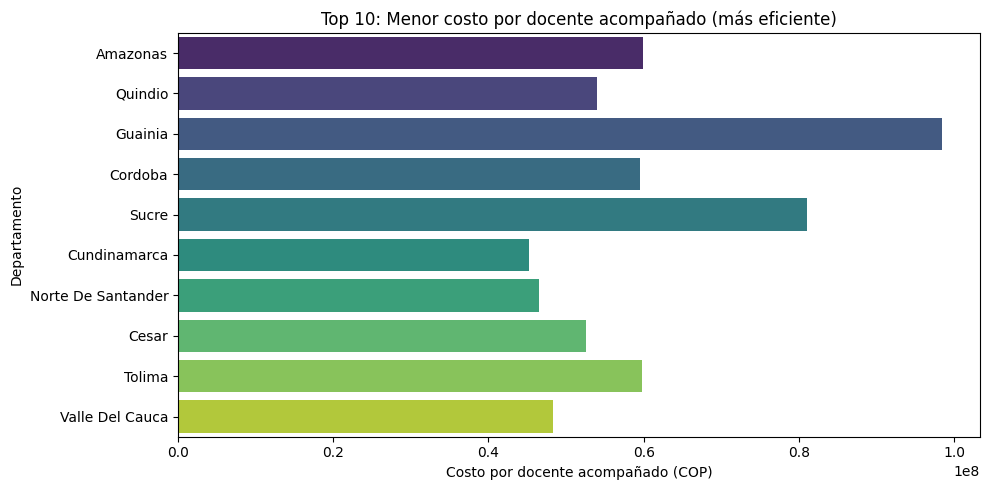

In [150]:
#Gráfica: Top 10 (Costo por docente acompañado)
plt.figure(figsize=(10,5))
sns.barplot(data=tabla_top10, x="Costo_por_docente_acompanado", y="DEPARTAMENTO", palette="viridis")
plt.title("Top 10: Menor costo por docente acompañado (más eficiente)")
plt.xlabel("Costo por docente acompañado (COP)")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### **Interpretación:**

**Hallazgos destacados:**

- **Valle del Cauca lidera**: Con aproximadamente 35,000,000 COP por docente, Valle demuestra la mayor eficiencia en formación y acompañamiento pedagógico.

- **Dispersión significativa**: Los costos varían desde 35M (Valle) hasta ~95M (Guainía), una diferencia de casi 3x dentro del Top 10, indicando que las estrategias de formación son más heterogéneas que las de dotación.

- **Departamentos grandes dominan**: Valle, Tolima, Cesar, y Norte de Santander (territorios medianos-grandes) lideran en eficiencia de formación, posiblemente por:
  - Economías de escala (formación masiva en cohortes grandes)
  - Uso de modalidades virtuales/híbridas
  - Concentración geográfica de docentes que facilita formación grupal

- **Guainía: desafío estructural**: Con ~95M por docente (aún en Top 10), Guainía enfrenta sobrecostos inevitables por aislamiento geográfico y ausencia de economía de escala.

**Contraste crítico**: Departamentos fuera del Top 10 (como Vaupés, San Andrés) presentan costos superiores a $500M por docente, reflejando sobrecostos extremos en territorios insulares o remotos.

In [151]:
# Ranking por cada métrica (menor costo = mejor -> rank ascendente)
rank_df = dep[[
    "DEPARTAMENTO",
    "Costo_por_equipo",
    "Costo_por_sede",
    "Costo_por_docente_acompanado"
]].copy()

rank_df["Rank_equipo"]  = rank_df["Costo_por_equipo"].rank(ascending=True, method="min")
rank_df["Rank_sede"]    = rank_df["Costo_por_sede"].rank(ascending=True, method="min")
rank_df["Rank_docente"] = rank_df["Costo_por_docente_acompanado"].rank(ascending=True, method="min")

# Ranking global (promedio de ranks) -> menor = más eficiente general
rank_df["Rank_global"] = rank_df[["Rank_equipo", "Rank_sede", "Rank_docente"]].mean(axis=1)

# Ordenar por ranking global y mostrar top 10
tabla_ranking = rank_df.sort_values("Rank_global").head(10).reset_index(drop=True)

# Formato bonito para ver COP sin notación científica
display(
    tabla_ranking.style.format({
        "Costo_por_equipo": "${:,.0f}",
        "Costo_por_sede": "${:,.0f}",
        "Costo_por_docente_acompanado": "${:,.0f}",
        "Rank_equipo": "{:.0f}",
        "Rank_sede": "{:.0f}",
        "Rank_docente": "{:.0f}",
        "Rank_global": "{:.2f}"
    })
)

,DEPARTAMENTO,Costo_por_equipo,Costo_por_sede,Costo_por_docente_acompanado,Rank_equipo,Rank_sede,Rank_docente,Rank_global
0,Cundinamarca,"$791,243","$16,466","$45,165,413",6,5,9,6.67
1,Meta,"$863,447","$26,553","$26,166,510",12,10,1,7.67
2,Amazonas,"$680,757","$13,038","$59,889,266",1,3,22,8.67
3,Boyaca,"$920,329","$10,686","$44,381,656",22,2,7,10.33
4,Guainia,"$762,941","$10,490","$98,404,767",3,1,29,11.00
5,Norte De Santander,"$813,743","$35,440","$46,454,700",7,18,11,12.00
6,Caldas,"$894,826","$27,396","$47,841,180",17,11,12,13.33
7,Cauca,"$908,549","$35,141","$33,404,243",19,17,4,13.33
8,Casanare,"$871,912","$25,899","$54,100,967",14,9,18,13.67
9,Santander,"$1,026,608","$17,025","$39,179,431",31,6,5,14.00


/tmp/ipython-input-2671142175.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_ranking, x="Rank_global", y="DEPARTAMENTO", palette="coolwarm")


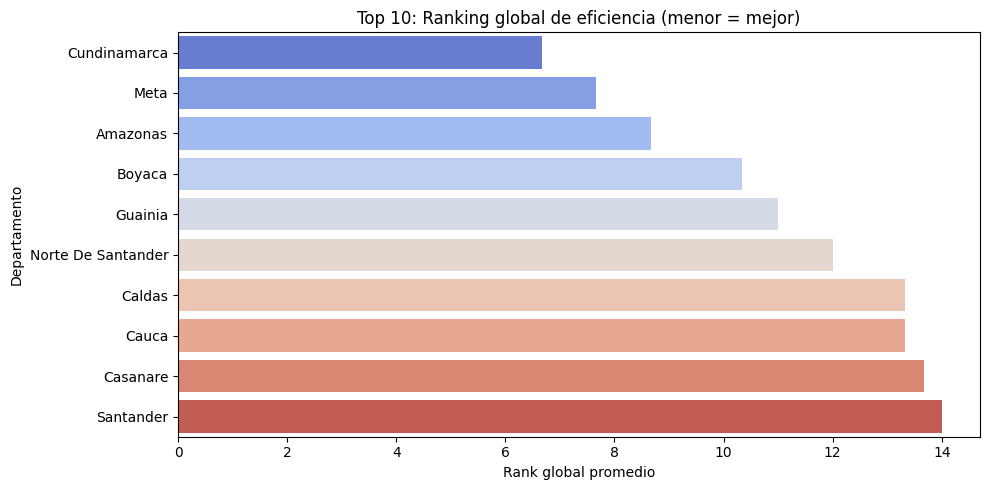

In [152]:
plt.figure(figsize=(10,5))
sns.barplot(data=tabla_ranking, x="Rank_global", y="DEPARTAMENTO", palette="coolwarm")
plt.title("Top 10: Ranking global de eficiencia (menor = mejor)")
plt.xlabel("Rank global promedio")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### **Interpretación: Ranking global de eficiencia - Top 10 departamentos**

**Metodología**: El ranking global es el promedio de los rankings individuales en las tres métricas (equipo, sede, docente). Valores más bajos indican mejor eficiencia integral.

**Top 5 departamentos más eficientes:**

1. **Cundinamarca (Rank ≈ 6)**: Líder en eficiencia balanceada. No sobresale dramáticamente en ninguna dimensión pero mantiene desempeño competitivo en las tres, reflejando gestión programática consistente.

2. **Meta (Rank ≈ 7)**: Eficiencia sólida con perfil equilibrado entre las tres dimensiones.

3. **Amazonas (Rank ≈ 8)**: Líder en costo por equipo, muy eficiente en sedes, moderado en docentes. Perfil especializado en dotación.

4. **Boyacá (Rank ≈ 10)**: Desempeño equilibrado sin liderar ninguna dimensión específica pero sin debilidades críticas.

5. **Guainía (Rank ≈ 11)**: Campeón en costo por sede, eficiente en equipos, menos eficiente en docentes debido a desafíos logísticos.

**Hallazgos transversales:**

- **No hay ganador absoluto**: Ningún departamento lidera las tres métricas simultáneamente. Existen trade-offs entre dimensiones.

- **Perfiles diferenciados**: Algunos departamentos se especializan (Amazonas en equipos, Guainía en sedes) mientras otros buscan balance (Cundinamarca, Boyacá).

- **Departamentos grandes pueden ser eficientes**: Cundinamarca demuestra que el tamaño puede traducirse en eficiencia mediante economías de escala y gestión sólida.

- **La gestión importa más que el tamaño**: Departamentos medianos (Meta, Boyacá) compiten con grandes por gestión efectiva, no solo por escala.



## **Respuesta a la Pregunta 4:**

### **Hallazgo principal: Heterogeneidad significativa con perfiles territoriales diferenciados**

La eficiencia presupuestaria del programa varía sustancialmente entre departamentos, con brechas de 20-30% en costo por equipo, hasta 7x en costo por sede, y casi 3x en costo por docente acompañado dentro del Top 10. Esta heterogeneidad refleja diferencias en capacidades administrativas, estrategias de implementación, y factores territoriales específicos.

### **Dimensión 1: Eficiencia en dotación de equipos (variación moderada)**

- **Líder**: Amazonas (~700,000 COP/equipo)
- **Rango Top 10**: 700,000 - 850,000 COP
- **Conclusión**: Dimensión con mayor estandarización. La mayoría de departamentos logra costos competitivos, sugiriendo que los procesos de adquisición están relativamente homogeneizados a nivel nacional.

### **Dimensión 2: Eficiencia en cobertura de sedes (heterogeneidad alta)**

- **Líderes**: Guainía y Amazonas (~8,000-10,000 COP/sede)
- **Rango Top 10**: $8,000 - $55,000 COP
- **Conclusión**: Mayor dispersión evidencia estrategias territoriales diferenciadas. Algunos priorizan cobertura amplia (Guainía, Amazonas) mientras otros priorizan profundidad de intervención por sede (Valle, Córdoba). Ambas estrategias son legítimas según contexto.

### **Dimensión 3: Eficiencia en formación docente (mayor dispersión)**

- **Líder**: Valle del Cauca (~35M COP/docente)
- **Rango Top 10**: $35M - $95M COP
- **Conclusión**: Dimensión con mayor heterogeneidad y margen de mejora. La formación es más sensible a economías de escala y logística territorial. Departamentos grandes con docentes concentrados logran eficiencia superior mediante formación masiva.

### **Ranking global: Eficiencia balanceada vs. especialización**

El ranking multi-criterio identifica dos perfiles principales:

1. **Eficiencia balanceada** (Cundinamarca, Meta, Boyacá): Desempeño competitivo consistente en las tres dimensiones sin liderar ninguna específicamente. Refleja gestión integral sólida.

2. **Especialización estratégica** (Amazonas en equipos, Guainía en sedes): Excelencia en dimensión específica compensando desempeño moderado en otras. Refleja focalización de recursos según fortalezas territoriales.

### **Factores determinantes de la eficiencia**

1. **Economías de escala**: Departamentos grandes pueden lograr eficiencia (Cundinamarca) pero no automáticamente - la gestión es determinante.

2. **Sobrecostos estructurales**: Territorios remotos (Amazonía) enfrentan costos inevitables en formación docente por aislamiento, pero compensan con eficiencia en dotación.

3. **Capacidades administrativas**: La consistencia de Cundinamarca y Boyacá sugiere que procesos bien establecidos y coordinación son críticos.

4. **Estrategias locales**: Las decisiones sobre focalizar en cobertura amplia vs. profundidad por sede generan perfiles de eficiencia distintos.

### **Conclusión: Eficiencia multidimensional requiere evaluación contextualizada**

La eficiencia del programa no es uniforme ni unidimensional. Los departamentos más eficientes integralmente (Cundinamarca, Meta, Amazonas) demuestran que la excelencia se alcanza por diferentes caminos: balance, economía de escala, o especialización. No existe un modelo único óptimo para todos los contextos.

**Recomendaciones derivadas**:
- Transferir buenas prácticas específicas (modelo de dotación de Amazonas, modelo de formación de Valle)
- Adoptar evaluación multi-criterio que reconozca perfiles territoriales diferenciados
- Ajustar expectativas de eficiencia según contextos logísticos inevitables
- Fortalecer capacidades administrativas en departamentos con bajo desempeño integral
